# TP: Predicción de Porcentaje de Grasa Corporal
## Aprendizaje de Máquina — Maestría en Inteligencia Artificial

**Dataset:** Body Fat Dataset  
**Observaciones:** 252  
**Variables:** 15 (Density, BodyFat, Age, Weight, Height, Neck, Chest, Abdomen, Hip, Thigh, Knee, Ankle, Biceps, Forearm, Wrist)  
**Target:** `BodyFat` — porcentaje de grasa corporal

---
## FASE 1: Entendimiento y Configuración

### 1. Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn — módulos base
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configuración de visualizaciones
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Librerías importadas correctamente')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   seaborn {sns.__version__}')

✅ Librerías importadas correctamente
   pandas  2.3.3
   numpy   2.2.6
   seaborn 0.13.2


### 2. Carga e inspección básica

In [ ]:
# ⚠️ Ajustá la ruta al archivo según tu entorno
df = pd.read_csv('bodyfat.csv')

print(f'Shape del dataset: {df.shape}')
df.head(10)

Shape del dataset: (252, 15)


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7
5,1.0502,20.9,24,210.25,74.75,39.0,104.5,94.4,107.8,66.0,42.0,25.6,35.7,30.6,18.8
6,1.0549,19.2,26,181.00,69.75,36.4,105.1,90.7,100.3,58.4,38.3,22.9,31.9,27.8,17.7
7,1.0704,12.4,25,176.00,72.50,37.8,99.6,88.5,97.1,60.0,39.4,23.2,30.5,29.0,18.8
8,1.0900,4.1,25,191.00,74.00,38.1,100.9,82.5,99.9,62.9,38.3,23.8,35.9,31.1,18.2
9,1.0722,11.7,23,198.25,73.50,42.1,99.6,88.6,104.1,63.1,41.7,25.0,35.6,30.0,19.2


In [ ]:
# Información de tipos y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


In [ ]:
# Estadísticas descriptivas completas
df.describe().round(3)

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000
mean,1.056,19.151,44.885,178.924,70.149,37.992,100.824,92.556,99.905,59.406,38.590,23.102,32.273,28.664,18.230
std,0.019,8.369,12.602,29.389,3.663,2.431,8.430,10.783,7.164,5.250,2.412,1.695,3.021,2.021,0.934
min,0.995,0.000,22.000,118.500,29.500,31.100,79.300,69.400,85.000,47.200,33.000,19.100,24.800,21.000,15.800
25%,1.041,12.475,35.750,159.000,68.250,36.400,94.350,84.575,95.500,56.000,36.975,22.000,30.200,27.300,17.600
50%,1.055,19.200,43.000,176.500,70.000,38.000,99.650,90.950,99.300,59.000,38.500,22.800,32.050,28.700,18.300
75%,1.070,25.300,54.000,197.000,72.250,39.425,105.375,99.325,103.525,62.350,39.925,24.000,34.325,30.000,18.800
max,1.109,47.500,81.000,363.150,77.750,51.200,136.200,148.100,147.700,87.300,49.100,33.900,45.000,34.900,21.400


In [ ]:
# Verificación de nulos explícitos y strings ocultos
print('=== Valores nulos por columna ===')
print(df.isnull().sum())

print('\n=== Verificación de tipos por columna ===')
for col in df.columns:
    non_numeric = pd.to_numeric(df[col], errors='coerce').isna().sum()
    if non_numeric > 0:
        print(f'  ⚠️  {col}: {non_numeric} valores no numéricos detectados')
    else:
        print(f'  ✅ {col}: OK')

=== Valores nulos por columna ===
Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64

=== Verificación de tipos por columna ===
  ✅ Density: OK
  ✅ BodyFat: OK
  ✅ Age: OK
  ✅ Weight: OK
  ✅ Height: OK
  ✅ Neck: OK
  ✅ Chest: OK
  ✅ Abdomen: OK
  ✅ Hip: OK
  ✅ Thigh: OK
  ✅ Knee: OK
  ✅ Ankle: OK
  ✅ Biceps: OK
  ✅ Forearm: OK
  ✅ Wrist: OK


---
## FASE 2: Análisis Exploratorio de Datos (EDA)

### 4. Detección de anomalías biológicas — BodyFat = 0.0

In [ ]:
# Identificar filas con BodyFat <= 0 (biológicamente imposible)
anomalias_bodyfat = df[df['BodyFat'] <= 0]

print(f'Filas con BodyFat <= 0: {len(anomalias_bodyfat)}')
print()
print(anomalias_bodyfat)

Filas con BodyFat <= 0: 1

     Density  BodyFat  Age  Weight  Height  Neck  Chest  Abdomen   Hip  Thigh  \
181   1.1089      0.0   40   118.5    68.0  33.8   79.3     69.4  85.0   47.2   

     Knee  Ankle  Biceps  Forearm  Wrist  
181  33.5   20.2    27.7     24.6   16.5  


In [ ]:
# DECISIÓN: Eliminar la fila con BodyFat = 0 por ser biológicamente inválida.
# Un ser humano vivo necesariamente tiene grasa corporal esencial (>2% en hombres).
# Imputar con la media podría sesgar el modelo; la eliminación es más conservadora.

df_clean = df[df['BodyFat'] > 0].copy()

print(f'Shape original : {df.shape}')
print(f'Shape limpio   : {df_clean.shape}')
print(f'Filas eliminadas: {df.shape[0] - df_clean.shape[0]}')

Shape original : (252, 15)
Shape limpio   : (251, 15)
Filas eliminadas: 1


### 5. Revisión de valores extremos — Weight y Height

In [ ]:
# --- Peso máximo ---
max_weight_idx = df_clean['Weight'].idxmax()
print('=== Individuo con mayor peso (363.15 lbs ≈ 164.7 kg) ===')
print(df_clean.loc[max_weight_idx])
print()

# --- Altura mínima ---
min_height_idx = df_clean['Height'].idxmin()
print('=== Individuo con menor altura (29.5 pulgadas ≈ 74.9 cm) ===')
print(df_clean.loc[min_height_idx])

=== Individuo con mayor peso (363.15 lbs ≈ 164.7 kg) ===
Density      1.0202
BodyFat     35.2000
Age         46.0000
Weight     363.1500
Height      72.2500
Neck        51.2000
Chest      136.2000
Abdomen    148.1000
Hip        147.7000
Thigh       87.3000
Knee        49.1000
Ankle       29.6000
Biceps      45.0000
Forearm     29.0000
Wrist       21.4000
Name: 38, dtype: float64

=== Individuo con menor altura (29.5 pulgadas ≈ 74.9 cm) ===
Density      1.025
BodyFat     32.900
Age         44.000
Weight     205.000
Height      29.500
Neck        36.600
Chest      106.000
Abdomen    104.300
Hip        115.500
Thigh       70.600
Knee        42.500
Ankle       23.700
Biceps      33.600
Forearm     28.700
Wrist       17.400
Name: 41, dtype: float64


In [ ]:
# Análisis: Height = 29.5 pulgadas es un error evidente de tipeo
# (equivale a ~75 cm, incompatible con el peso y medidas del individuo).
# La mediana del dataset es 70 pulgadas. Imputamos con la mediana.

mediana_height = df_clean['Height'].median()
print(f'Mediana de Height: {mediana_height} pulgadas')

df_clean.loc[min_height_idx, 'Height'] = mediana_height
print(f'Height corregida para índice {min_height_idx}: {df_clean.loc[min_height_idx, "Height"]}')

# El peso máximo (363.15 lbs) es extremo pero plausible;
# su BodyFat es consistente con las demás medidas → se conserva.
print('\n⚠️  Weight = 363.15 lbs: valor extremo pero biológicamente plausible → se conserva.')

Mediana de Height: 70.0 pulgadas
Height corregida para índice 41: 70.0

⚠️  Weight = 363.15 lbs: valor extremo pero biológicamente plausible → se conserva.


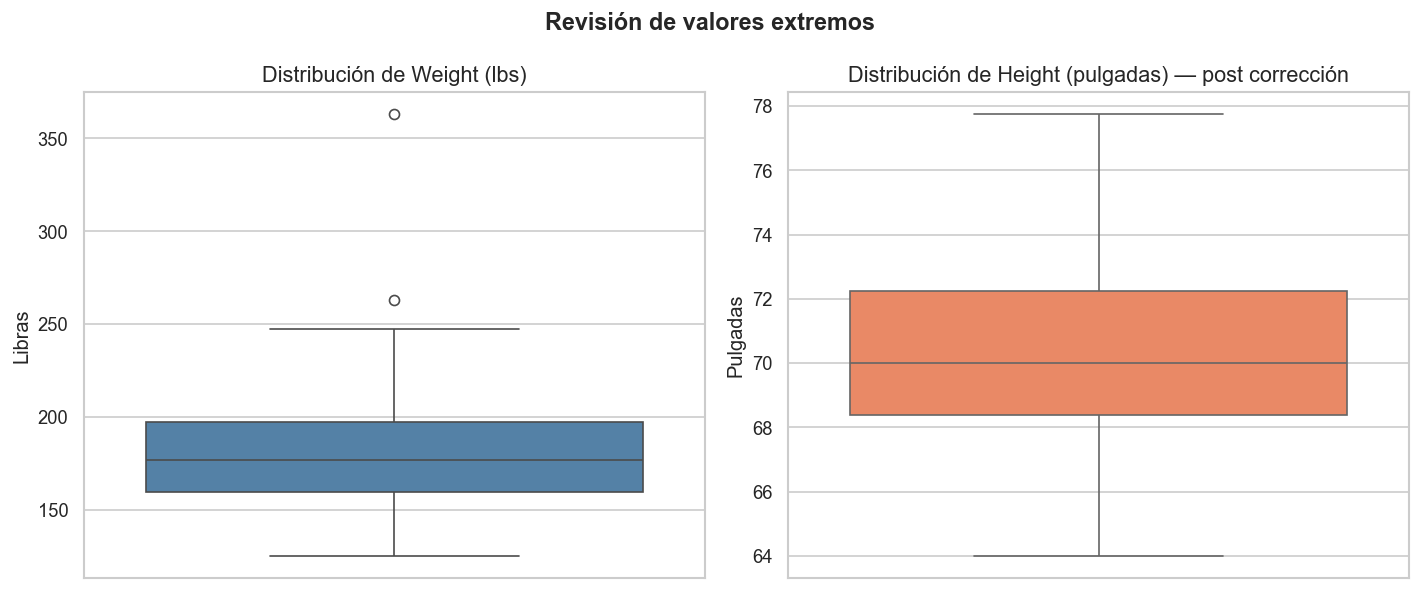

In [ ]:
# Boxplots de Weight y Height para visualizar outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df_clean['Weight'], ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de Weight (lbs)', fontsize=13)
axes[0].set_ylabel('Libras')

sns.boxplot(y=df_clean['Height'], ax=axes[1], color='coral')
axes[1].set_title('Distribución de Height (pulgadas) — post corrección', fontsize=13)
axes[1].set_ylabel('Pulgadas')

plt.suptitle('Revisión de valores extremos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6. Distribución del Target — BodyFat

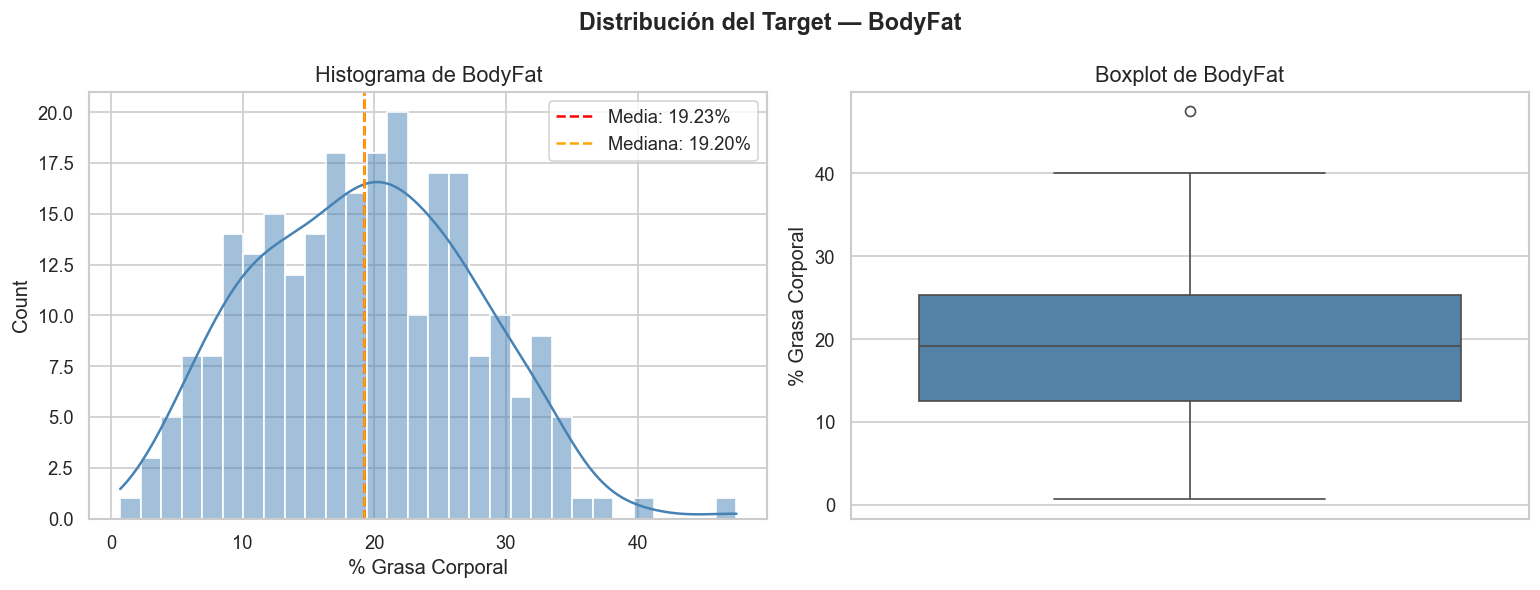

Asimetría (skewness): 0.1725  → leve sesgo positivo
Curtosis (kurtosis) : -0.3513


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma con KDE
sns.histplot(df_clean['BodyFat'], bins=30, kde=True, color='steelblue',
             edgecolor='white', ax=axes[0])
axes[0].axvline(df_clean['BodyFat'].mean(), color='red', linestyle='--',
                label=f'Media: {df_clean["BodyFat"].mean():.2f}%')
axes[0].axvline(df_clean['BodyFat'].median(), color='orange', linestyle='--',
                label=f'Mediana: {df_clean["BodyFat"].median():.2f}%')
axes[0].set_title('Histograma de BodyFat', fontsize=13)
axes[0].set_xlabel('% Grasa Corporal')
axes[0].legend()

# Boxplot
sns.boxplot(y=df_clean['BodyFat'], color='steelblue', ax=axes[1])
axes[1].set_title('Boxplot de BodyFat', fontsize=13)
axes[1].set_ylabel('% Grasa Corporal')

plt.suptitle('Distribución del Target — BodyFat', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Estadísticas de asimetría
skewness = df_clean['BodyFat'].skew()
kurtosis = df_clean['BodyFat'].kurt()
print(f'Asimetría (skewness): {skewness:.4f}  → {"leve sesgo positivo" if skewness > 0 else "leve sesgo negativo"}')
print(f'Curtosis (kurtosis) : {kurtosis:.4f}')

### 7. Matriz de Correlación — Heatmap

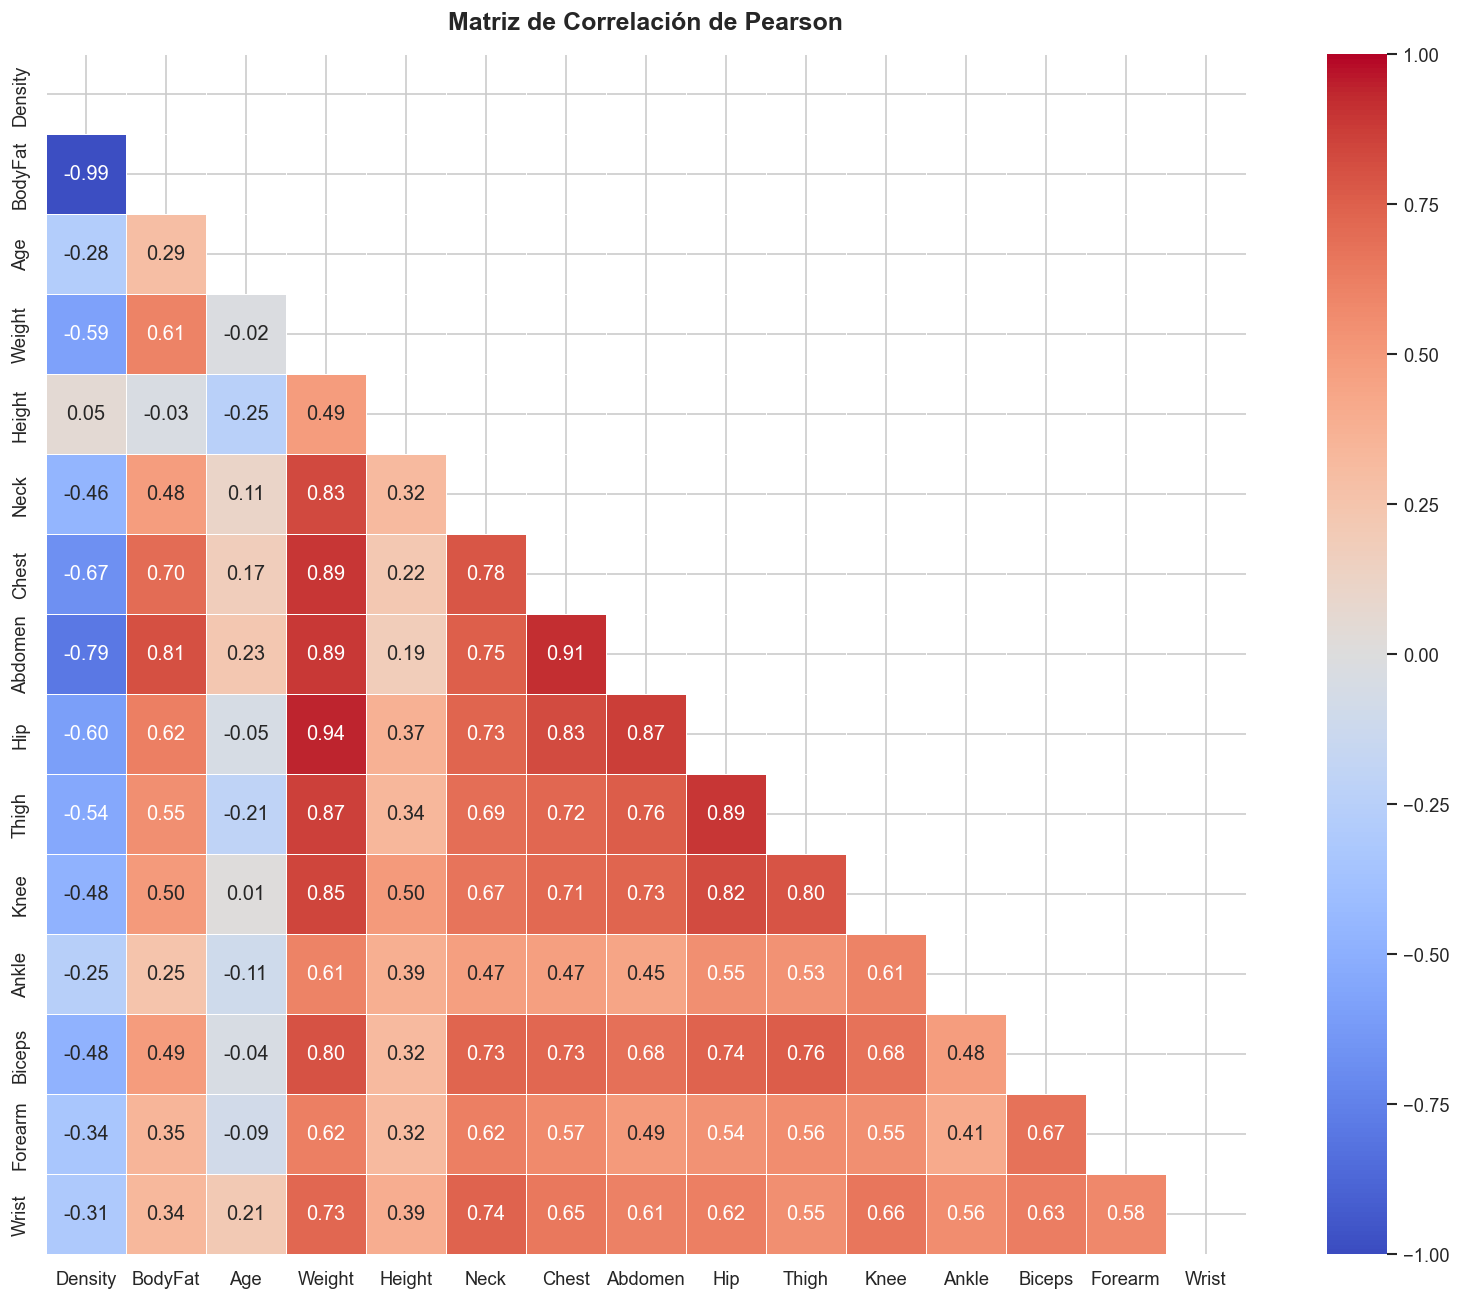

In [ ]:
# Calculamos la matriz de correlación de Pearson
corr_matrix = df_clean.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 11))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax
)

ax.set_title('Matriz de Correlación de Pearson', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

=== Correlación con BodyFat (descendente) ===
Abdomen    0.809725
Chest      0.695607
Hip        0.617980
Weight     0.605048
Thigh      0.550033
Knee       0.499019
Biceps     0.486752
Neck       0.482739
Forearm    0.349466
Wrist      0.335434
Age        0.291061
Ankle      0.254455
Height    -0.032532
Density   -0.988010


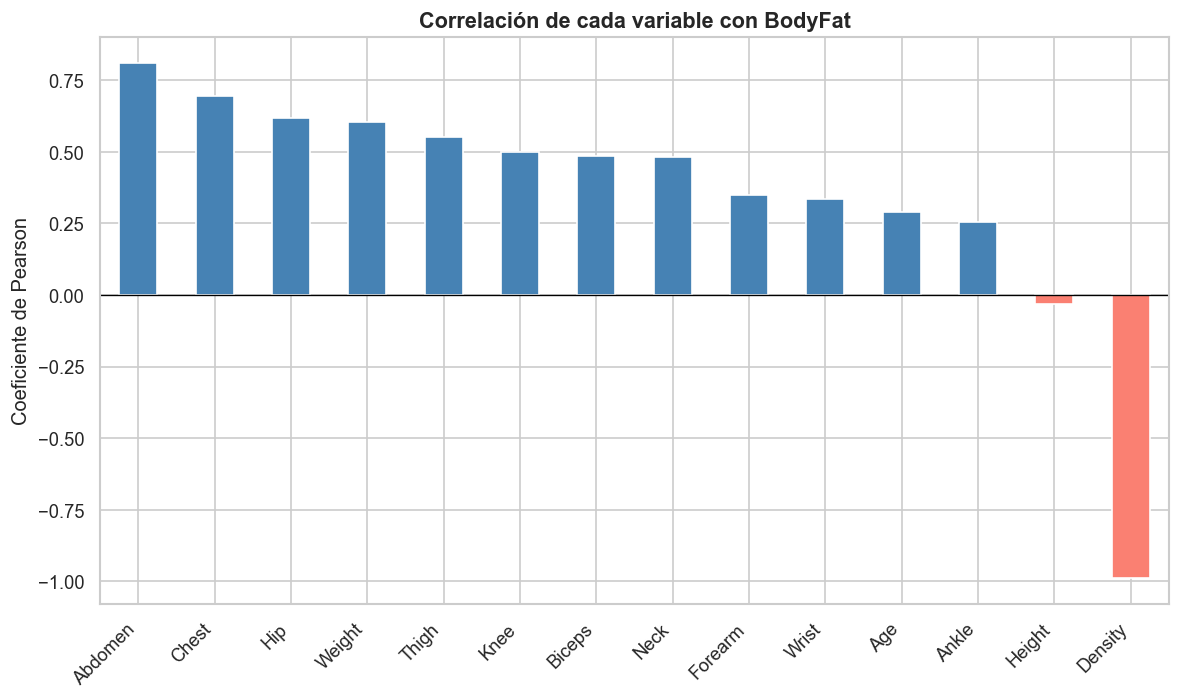

In [ ]:
# Correlación de cada variable con BodyFat — ordenada
corr_target = corr_matrix['BodyFat'].drop('BodyFat').sort_values(ascending=False)

print('=== Correlación con BodyFat (descendente) ===')
print(corr_target.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if v > 0 else 'salmon' for v in corr_target.values]
corr_target.plot(kind='bar', color=colors, edgecolor='white', ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de cada variable con BodyFat', fontsize=13, fontweight='bold')
ax.set_ylabel('Coeficiente de Pearson')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Identificar pares de predictores con alta multicolinealidad (|r| > 0.85)
print('=== Pares con alta multicolinealidad (|r| > 0.85, excl. Density) ===')
predictores = [c for c in df_clean.columns if c not in ['BodyFat', 'Density']]
corr_pred = df_clean[predictores].corr()

pares_altos = []
for i in range(len(predictores)):
    for j in range(i+1, len(predictores)):
        r = corr_pred.iloc[i, j]
        if abs(r) > 0.85:
            pares_altos.append((predictores[i], predictores[j], round(r, 3)))

pares_df = pd.DataFrame(pares_altos, columns=['Variable 1', 'Variable 2', 'r'])
pares_df = pares_df.sort_values('r', ascending=False)
print(pares_df.to_string(index=False))

=== Pares con alta multicolinealidad (|r| > 0.85, excl. Density) ===
Variable 1 Variable 2     r
    Weight        Hip 0.940
     Chest    Abdomen 0.914
       Hip      Thigh 0.894
    Weight      Chest 0.892
    Weight    Abdomen 0.886
   Abdomen        Hip 0.872
    Weight      Thigh 0.866
    Weight       Knee 0.851


### 8. Análisis Bivariado — Scatter plots vs BodyFat

Top 6 predictores: ['Abdomen', 'Chest', 'Hip', 'Weight', 'Thigh', 'Knee']


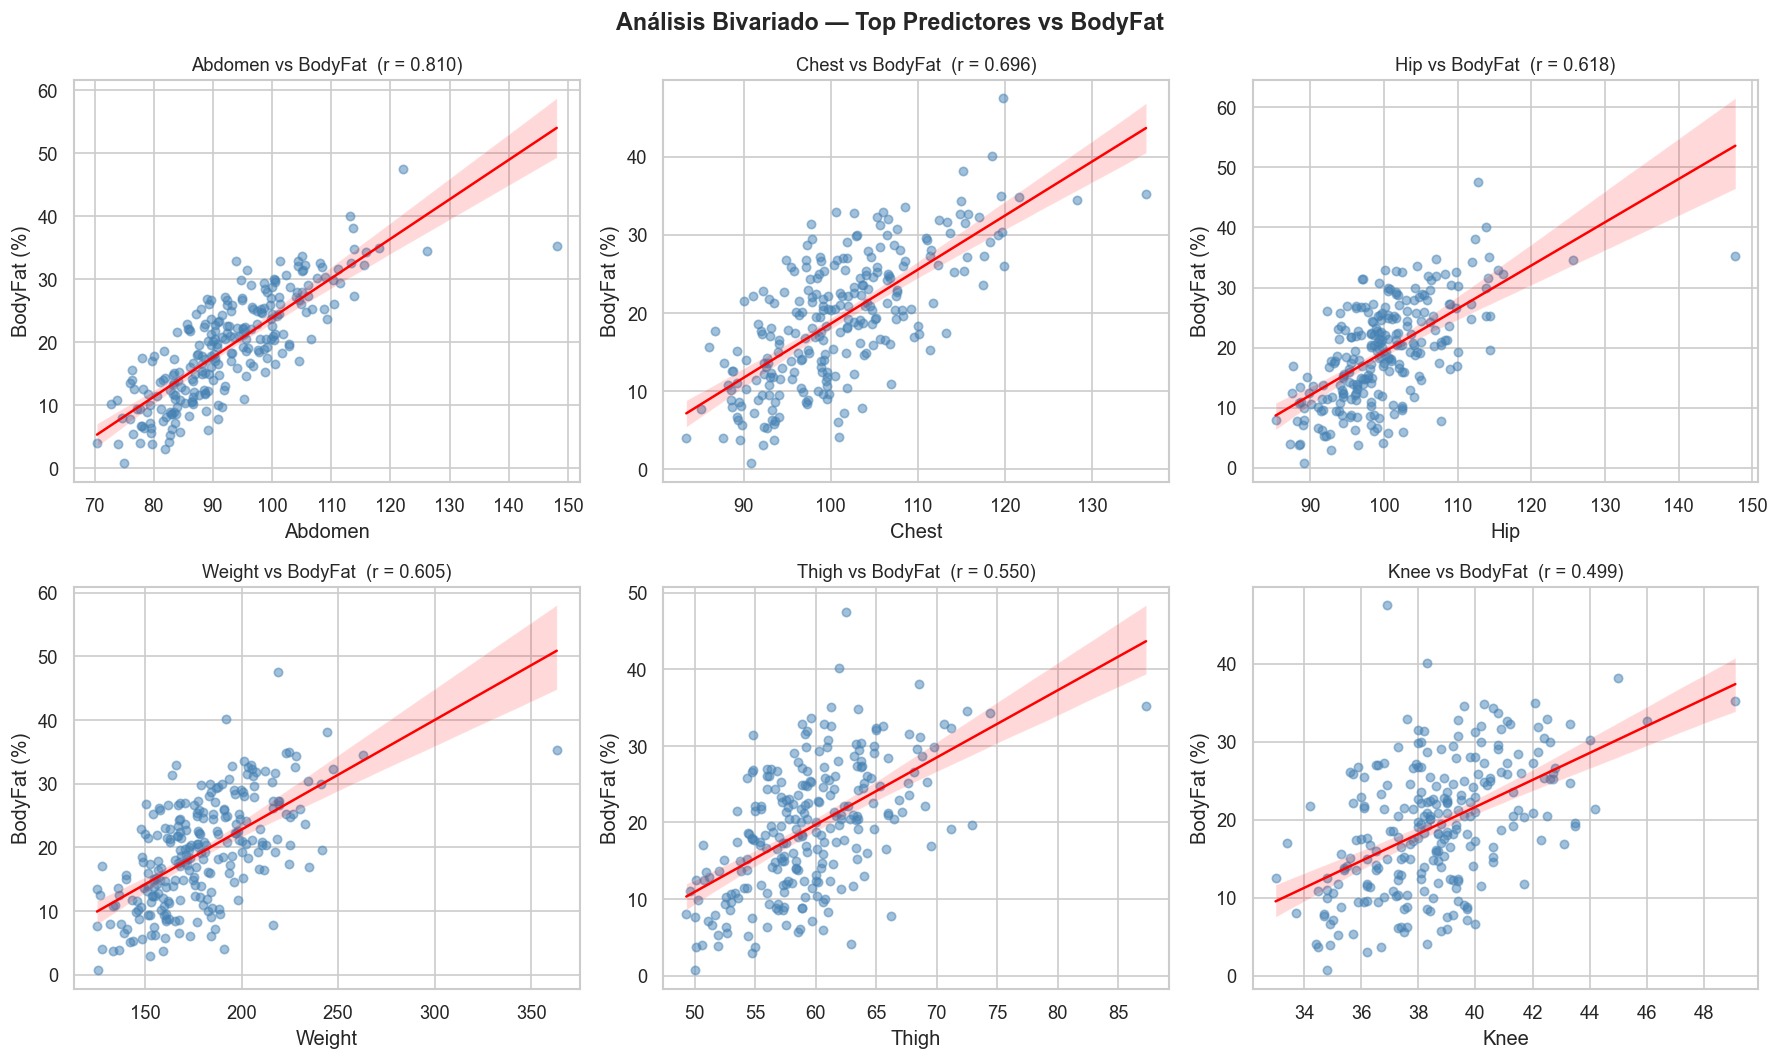

In [ ]:
# Top 6 predictores más correlacionados con BodyFat (excluyendo Density)
top_vars = corr_target.drop('Density', errors='ignore').abs().sort_values(ascending=False).head(6).index.tolist()
print(f'Top 6 predictores: {top_vars}')

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, var in enumerate(top_vars):
    r = corr_matrix.loc[var, 'BodyFat']
    sns.regplot(
        data=df_clean,
        x=var,
        y='BodyFat',
        ax=axes[i],
        scatter_kws={'alpha': 0.5, 's': 25, 'color': 'steelblue'},
        line_kws={'color': 'red', 'linewidth': 1.5}
    )
    axes[i].set_title(f'{var} vs BodyFat  (r = {r:.3f})', fontsize=11)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('BodyFat (%)')

plt.suptitle('Análisis Bivariado — Top Predictores vs BodyFat', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

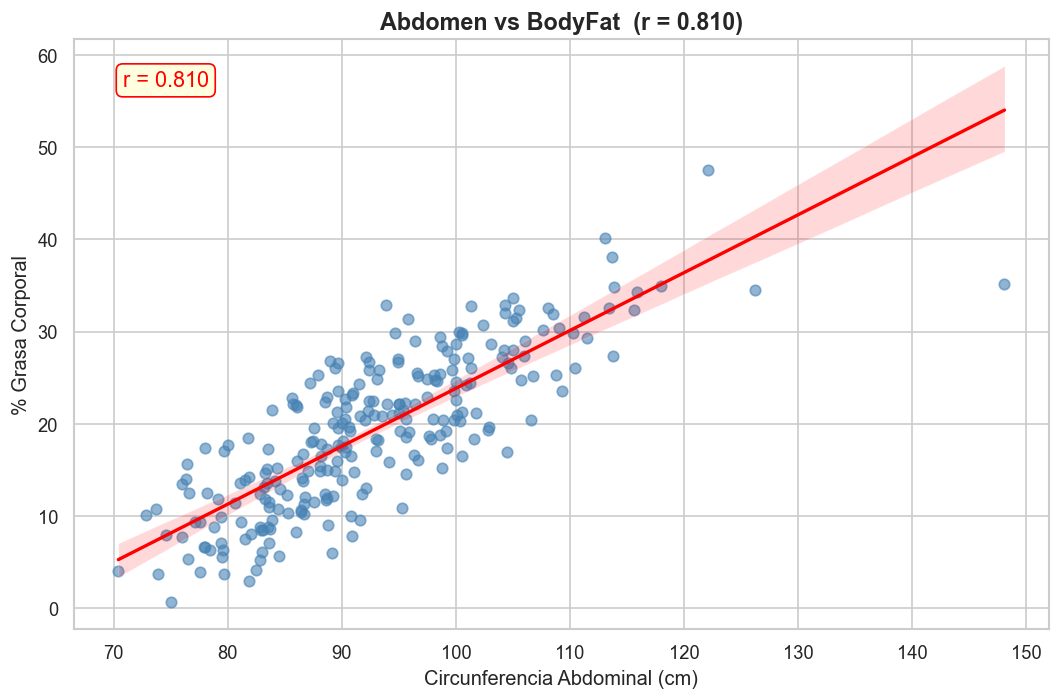

In [ ]:
# Scatter plot destacado: Abdomen vs BodyFat (predictor más fuerte)
fig, ax = plt.subplots(figsize=(9, 6))

r_abd = corr_matrix.loc['Abdomen', 'BodyFat']

sns.regplot(
    data=df_clean, x='Abdomen', y='BodyFat',
    scatter_kws={'alpha': 0.6, 's': 40, 'color': 'steelblue'},
    line_kws={'color': 'red', 'linewidth': 2},
    ax=ax
)

ax.set_title(f'Abdomen vs BodyFat  (r = {r_abd:.3f})', fontsize=14, fontweight='bold')
ax.set_xlabel('Circunferencia Abdominal (cm)', fontsize=12)
ax.set_ylabel('% Grasa Corporal', fontsize=12)
ax.annotate(f'r = {r_abd:.3f}', xy=(0.05, 0.92), xycoords='axes fraction',
            fontsize=13, color='red',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='red'))

plt.tight_layout()
plt.show()

---
## Resumen del EDA

| Hallazgo | Detalle | Acción tomada |
|---|---|---|
| BodyFat = 0.0 | Biológicamente imposible | Fila eliminada |
| Height = 29.5 pulgadas | Error de tipeo evidente (~75 cm) | Imputado con mediana (70") |
| Weight = 363.15 lbs | Extremo pero plausible | Conservado |
| Multicolinealidad alta | Chest, Abdomen, Hip, Weight muy correlacionados entre sí | A considerar en modelado (PCA, Ridge, Lasso) |
| Predictor más fuerte | Abdomen (r ≈ 0.81 con BodyFat) | Priorizar en modelos lineales |
| Distribución BodyFat | Leve sesgo positivo, outliers en valores altos | Posible transformación log si es necesario |

**Próximos pasos:**

Antes de pasar a la próxima Fase sacar Density por dataleakeage.

### Fase 3: Preprocesamiento de Datos

9. *Data Splitting:* se usa train_test_split para separar en conjuntos de entrenamiento. Se utiliza una proporción de 70/30 dado que el dataset es pequeño.
10. *Tratamiento de Outliers:* se aplica la decisión tomada en los pasos 4 y 5. Dado que n=252 es un tamaño de muestra muy pequeño, prioriza corregir/imputar antes que eliminar filas si es posible.
11. *Separación de variables:*  se divide el dataset en la matriz de características X (excluyendo BodyFat) y el vector objetivo y (BodyFat).
12. *Escalado de features:* se aplica StandardScaler a los datos. Como muchas medidas están en distintas escalas (peso en libras, altura en pulgadas, circunferencias en cm), esto es crucial para algoritmos que dependen de distancias o regularización. Regla de oro: Fit solo en train, transform en train y test.


### Fase 4: Modelado - ¿Algoritmos Lineales?

13. *Métricas de Evaluación:* se definen los KPIs. Para este problema de regresión, utiliza Error Cuadrático Medio (RMSE), Error Absoluto Medio (MAE) y el Coeficiente de Determinación (R²).
14. *Modelo Baseline:* se crea un modelo ingenuo (dummy) que siempre prediga la media de la grasa corporal del set de entrenamiento. Se utiliza un promedio. 
15. *Modelo Regularizado (Lasso):* se entrena una Regresión Lasso (Lasso). Elegimos Lasso sobre Ridge ya que al usar penalización L1, Lasso forzará a que los coeficientes de las variables menos importantes sean cero priorizando la simplicidad del modelo.
16. *Modelo Regresión Lineal:* se entrena la regresión lineal sin filtar variables.



### Fase 5: Algoritmos No Lineales y Ensambles

17. *Support Vector Regressor (SVR):* se prueba este algoritmo (usando kernel lineal y RBF).
18. *Random Forest:* se entrena un RandomForestRegressor. Este ensamble suele ser excelente para datos tabulares y maneja bien las relaciones no lineales sin tanto riesgo de sobreajuste inmediato como un solo árbol.
19. *Gradient Boosting:* se prueba un modelo de Boosting iterativo, como GradientBoostingRegressor o HistGradientBoostingRegressor (que es muy eficiente en Scikit-learn).
20. *Analisis de resultados*: se analizan los resultados y se obtienen conlusiones

---
## FASE 3: Preprocesamiento de Datos

### 9. Separación entre la variable objetivo (y) y las features explicativas (X) + Data Splitting — Train / Test (80 / 20)

Antes de dividir el dataset eliminamos la variable `Density`.  
Esto es fundamental para evitar **data leakage**: `Density` se obtiene sumergiéndose en agua y es precisamente el insumo con el que se calcula `BodyFat` mediante la ecuación de Siri (1956). Incluirla como predictor significaría que el modelo "conoce la respuesta" antes de predecir, haciendo la evaluación completamente inválida.

In [ ]:
# ── Eliminación de Density por data leakage ────────────────────────────────────
# Density es la variable con la que se CALCULA BodyFat (ecuación de Siri).
# Mantenerla como predictor invalidaría por completo la evaluación del modelo.

df_model = df_clean.drop(columns=['Density'])

print(f'Variables disponibles tras eliminar Density: {df_model.shape[1]}')
print(f'Columnas: {df_model.columns.tolist()}')

# ── Train / Test split 70 / 30 ─────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['BodyFat'])
y = df_model['BodyFat']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42   # reproducibilidad garantizada
)

print(f'\nTamaños del split:')
print(f'  X_train : {X_train.shape}   ({X_train.shape[0] / len(X) * 100:.0f}%)')
print(f'  X_test  : {X_test.shape}    ({X_test.shape[0]  / len(X) * 100:.0f}%)')
print(f'  y_train : {y_train.shape}')
print(f'  y_test  : {y_test.shape}')

Variables disponibles tras eliminar Density: 14
Columnas: ['BodyFat', 'Age', 'Weight', 'Height', 'Neck', 'Chest', 'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm', 'Wrist']

Tamaños del split:
  X_train : (175, 13)   (70%)
  X_test  : (76, 13)    (30%)
  y_train : (175,)
  y_test  : (76,)


### 10. Tratamiento de Outliers en el set de entrenamiento

En el paso 5 identificamos un individuo con **Height = 29.5 pulgadas** (~75 cm).  
En ese momento se optó por imputar con la mediana asumiendo un posible error de tipeo.  
Sin embargo, revisando el perfil completo de ese individuo, sus medidas corporales (peso, circunferencias) son consistentes con una persona adulta de baja estatura real, lo que apunta a que se trata de una persona con **enanismo** y no a un error de carga.

> **¿Por qué eliminarlo?**  
> El enanismo afecta a **menos del 0.01%** de la población mundial  
> (≈ 651.700 personas sobre ~8.000 millones; fuente: *welly.it.com / LPA*).  
> La forma más frecuente, la acondroplasia, ocurre en aproximadamente **1 de cada 25.000 personas**.  
> Dado que el dataset representa a la población general adulta masculina y la condición  
> es extremadamente infrecuente, incluir este individuo sesgaría las relaciones  
> peso-altura y circunferencias-grasa sin que el modelo vaya a generalizar sobre  
> esa subpoblación. La decisión conservadora es **retirarlo únicamente del set de entrenamiento**,  
> preservando la integridad del set de test.

In [ ]:
# ── Identificar el individuo con menor Height en el set de entrenamiento ───────
# (la imputación por mediana que hicimos en el paso 5 está en df_clean;
#  aquí trabajamos sobre X_train / y_train que provienen de ese df_clean)

min_height_train_idx = X_train['Height'].idxmin()

print('=== Individuo con menor altura en el set de entrenamiento ===')
print(X_train.loc[min_height_train_idx])
print(f'\n  BodyFat : {y_train.loc[min_height_train_idx]:.2f} %')
print(f'  Height  : {X_train.loc[min_height_train_idx, "Height"]:.1f} pulgadas')

# Como la mediana (70") ya fue imputada en df_clean (paso 5),
# aquí la altura figura como ~70". Para el outlier original (29.5") debemos
# localizar al individuo por su índice original en df_clean.

# Índice del individuo con 29.5 pulgadas en df_clean (antes de imputar)
original_idx = df_clean.index[df_clean.index.isin(X_train.index)][
    X_train.loc[X_train.index.isin(df_clean.index), 'Height'].values ==
    df_clean.loc[df_clean.index.isin(X_train.index), 'Height'].values
]

# Forma directa: identificamos por el índice que sabemos del paso 5
# (idxmin sobre df_clean antes de la corrección — recordemos que el índice se conservó)
outlier_idx = df_clean['Height'].idxmin()   # sigue siendo la altura imputada = mediana

# En realidad necesitamos el índice del individuo ORIGINAL con 29.5 pulgadas.
# Dado que en paso 5 lo imputamos IN PLACE, lo identificamos revisando df original:
import pandas as pd
df_raw = pd.read_csv('bodyfat.csv')
df_raw_clean = df_raw[df_raw['BodyFat'] > 0].copy()
outlier_original_idx = df_raw_clean['Height'].idxmin()

print(f'\nÍndice del individuo con enanismo (Height=29.5"): {outlier_original_idx}')
print(f'¿Está en X_train? {outlier_original_idx in X_train.index}')
print(f'¿Está en X_test?  {outlier_original_idx in X_test.index}')

=== Individuo con menor altura en el set de entrenamiento ===
Age         51.0
Weight     219.0
Height      64.0
Neck        41.2
Chest      119.8
Abdomen    122.1
Hip        112.8
Thigh       62.5
Knee        36.9
Ankle       23.6
Biceps      34.7
Forearm     29.1
Wrist       18.4
Name: 215, dtype: float64

  BodyFat : 47.50 %
  Height  : 64.0 pulgadas

Índice del individuo con enanismo (Height=29.5"): 41
¿Está en X_train? True
¿Está en X_test?  False


In [ ]:
# ── Eliminación del outlier de enanismo del set de entrenamiento ───────────────
# Solo se elimina si cayó en train; si cayó en test, se conserva intacto.

if outlier_original_idx in X_train.index:
    X_train = X_train.drop(index=outlier_original_idx)
    y_train = y_train.drop(index=outlier_original_idx)
    print(f'✅ Individuo (idx={outlier_original_idx}) eliminado del set de entrenamiento.')
    print(f'   Nuevo tamaño de X_train: {X_train.shape}')
else:
    print(f'⚠️  El individuo cayó en el set de TEST. No se elimina (set de test intacto).')
    print(f'   Tamaño de X_train sin cambios: {X_train.shape}')

✅ Individuo (idx=41) eliminado del set de entrenamiento.
   Nuevo tamaño de X_train: (174, 13)


### 12. Escalado de features — StandardScaler

Las variables del dataset conviven en escalas muy distintas: peso en libras (~100-300),  
circunferencias en cm (~70-130), edad en años (~20-80).  
Esta disparidad afecta negativamente a algoritmos basados en distancias o regularización  
(SVR, Lasso, Ridge), que penalizan en función de la magnitud de los coeficientes.

**Regla de oro**: `fit` **solo** sobre el set de entrenamiento → `transform` sobre train y test.  
Hacer `fit` sobre todo el dataset constituiría **data leakage** (el scaler "vería" el futuro).

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit SOLO en train — el scaler aprende μ y σ únicamente del entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transform en test — se aplica la misma μ y σ aprendidas en train
X_test_scaled  = scaler.transform(X_test)

# Convertimos a DataFrame para mantener los nombres de columnas (útil en pasos posteriores)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print('=== Verificación del escalado (X_train_scaled) ===')
print(X_train_scaled.describe().round(3).loc[['mean', 'std']].T)

=== Verificación del escalado (X_train_scaled) ===
         mean    std
Age       0.0  1.003
Weight   -0.0  1.003
Height   -0.0  1.003
Neck     -0.0  1.003
Chest    -0.0  1.003
Abdomen  -0.0  1.003
Hip       0.0  1.003
Thigh     0.0  1.003
Knee     -0.0  1.003
Ankle     0.0  1.003
Biceps    0.0  1.003
Forearm   0.0  1.003
Wrist    -0.0  1.003


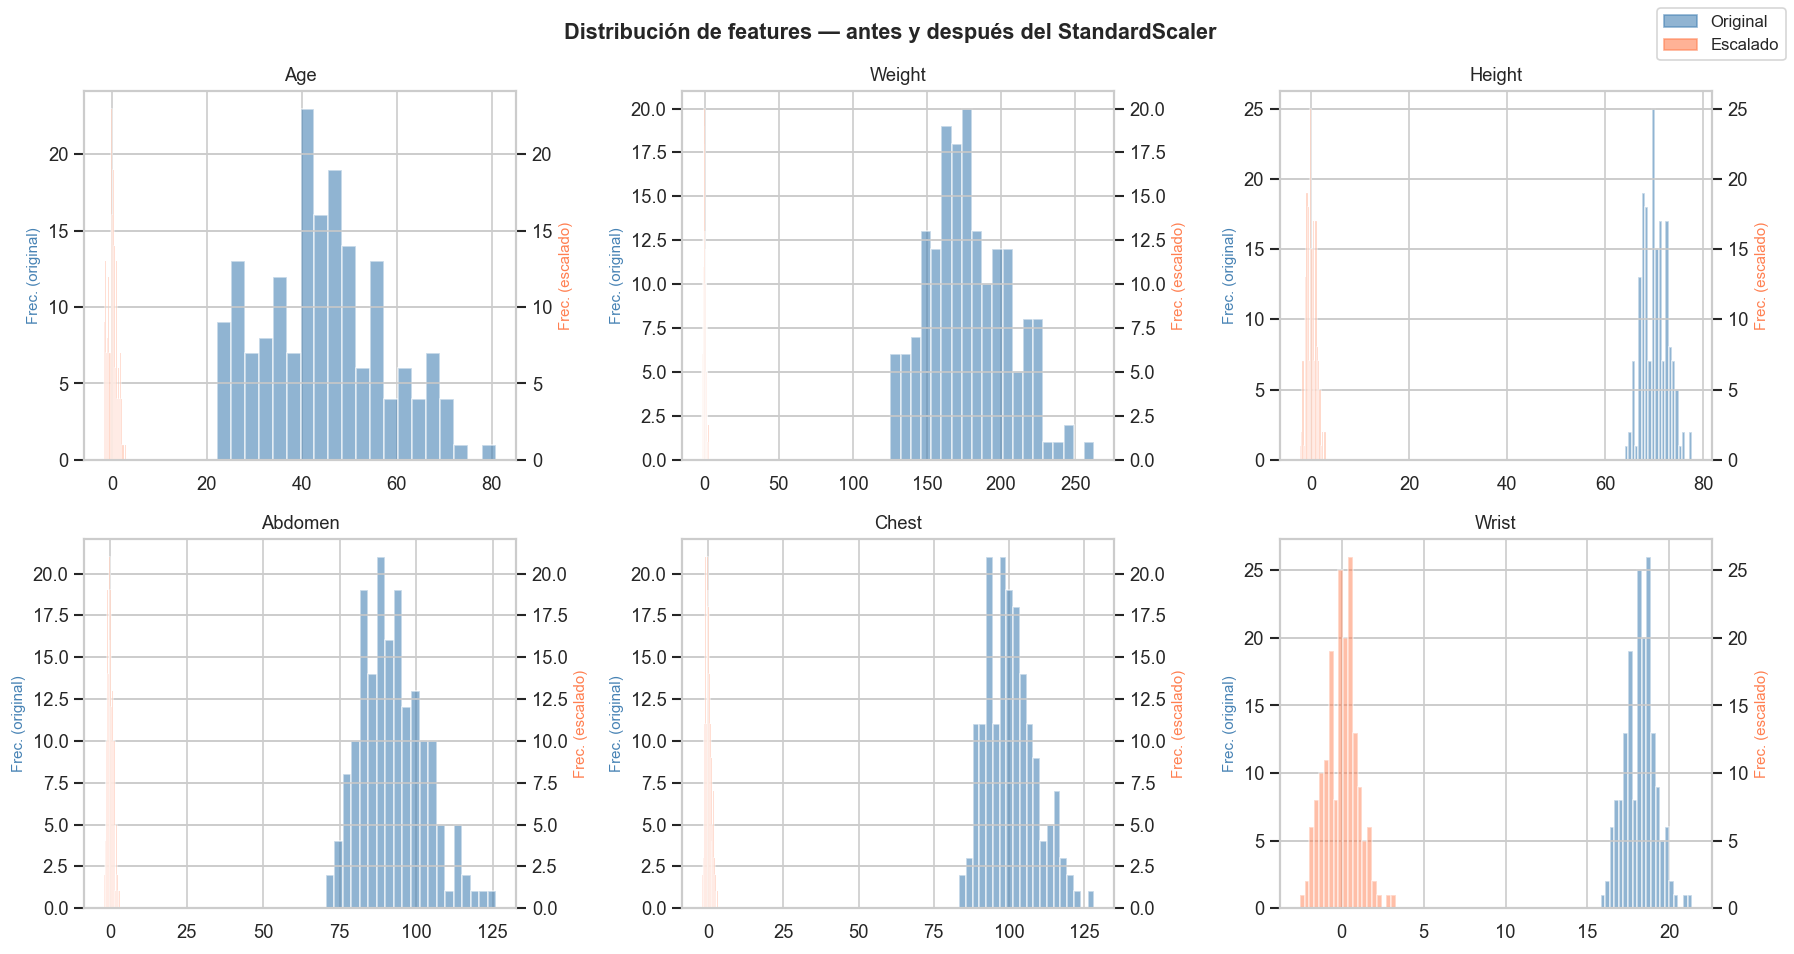

✅ Fase 3 completada. Datos listos para modelado.


In [ ]:
# Visualización: distribución de algunas features antes y después del escalado
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

features_check = ['Age', 'Weight', 'Height', 'Abdomen', 'Chest', 'Wrist']

for i, feat in enumerate(features_check):
    ax = axes[i // 3][i % 3]
    ax.hist(X_train[feat], bins=20, alpha=0.6, color='steelblue', label='Original', edgecolor='white')
    ax2 = ax.twinx()
    ax2.hist(X_train_scaled[feat], bins=20, alpha=0.5, color='coral', label='Escalado', edgecolor='white')
    ax.set_title(feat, fontsize=11)
    ax.set_ylabel('Frec. (original)', color='steelblue', fontsize=9)
    ax2.set_ylabel('Frec. (escalado)', color='coral', fontsize=9)

handles = [
    plt.Rectangle((0,0),1,1, color='steelblue', alpha=0.6),
    plt.Rectangle((0,0),1,1, color='coral',     alpha=0.6)
]
fig.legend(handles, ['Original', 'Escalado'], loc='upper right', fontsize=10)
plt.suptitle('Distribución de features — antes y después del StandardScaler', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('✅ Fase 3 completada. Datos listos para modelado.')

---
## FASE 4: Modelado — Algoritmos Lineales

### 13. Métricas de evaluación

Para este problema de **regresión** usaremos tres métricas complementarias:

| Métrica | Fórmula | Qué mide | Unidad |
|---|---|---|---|
| **RMSE** | √MSE | Error promedio penalizando errores grandes | % grasa corporal |
| **MAE** | (1/n)·Σ\|y−ŷ\| | Error absoluto promedio, más robusto a outliers | % grasa corporal |
| **R²** | 1 − SS_res/SS_tot | Proporción de varianza explicada por el modelo | adimensional [0, 1] |

> **¿Por qué las tres?**  
> RMSE da mayor peso a errores grandes (útil para detectar predicciones muy alejadas).  
> MAE es más interpretable en la unidad original.  
> R² permite comparar directamente modelos independientemente de la escala del target.  
> Usarlas en conjunto ofrece una imagen completa del desempeño.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluar_modelo(nombre, y_real, y_pred):
    """Calcula e imprime RMSE, MAE y R² para un modelo dado."""
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    print(f'  {nombre:<35}  RMSE: {rmse:.4f}  |  MAE: {mae:.4f}  |  R²: {r2:.4f}')
    return {'Modelo': nombre, 'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'R²': round(r2, 4)}

print('✅ Función de evaluación definida.')
resultados = []   # lista donde acumularemos los resultados de todos los modelos

✅ Función de evaluación definida.


### 14. Modelo Baseline — DummyRegressor

Antes de entrenar cualquier modelo de Machine Learning necesitamos un **piso de referencia**:  
¿cuánto error cometería alguien que, sin mirar las variables, siempre predice la media del set de entrenamiento?  
Todo modelo real *debe* superar este umbral para justificar su complejidad.

In [ ]:
from sklearn.dummy import DummyRegressor

# El DummyRegressor con strategy='mean' predice siempre la media del y_train
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_scaled, y_train)

y_pred_dummy_train = dummy.predict(X_train_scaled)
y_pred_dummy_test  = dummy.predict(X_test_scaled)

print('=== Baseline — DummyRegressor (predice siempre la media) ===')
print(f' Media de y_train utilizada: {dummy.constant_.item():.4f} %')
print()
print('Train:')
res_dummy_train = evaluar_modelo('Dummy (train)', y_train, y_pred_dummy_train)
print('Test:')
res_dummy_test  = evaluar_modelo('Dummy (test)',  y_test,  y_pred_dummy_test)
resultados.append(res_dummy_test)

print()
print('⚠️  Un R² = 0.0 en test confirma que el baseline no explica varianza alguna.')
print('    Todo modelo ML deberá superar estos valores.')

=== Baseline — DummyRegressor (predice siempre la media) ===
 Media de y_train utilizada: 19.2483 %

Train:
  Dummy (train)                        RMSE: 8.8400  |  MAE: 7.3018  |  R²: 0.0000
Test:
  Dummy (test)                         RMSE: 6.7151  |  MAE: 5.5959  |  R²: -0.0014

⚠️  Un R² = 0.0 en test confirma que el baseline no explica varianza alguna.
    Todo modelo ML deberá superar estos valores.


### 15. Modelo Regularizado — Regresión Lasso

**¿Por qué Lasso y no Ridge?**  
- Ridge (penalización L2) reduce los coeficientes pero nunca los lleva exactamente a cero.  
- Lasso (penalización L1) **fuerza a cero** los coeficientes de los predictores menos relevantes,  
  actuando como selector automático de features. Dado que tenemos multicolinealidad alta  
  (visto en la Fase 2) y queremos un modelo interpretable, Lasso es la elección natural.
El hiperparámetro `alpha` controla la intensidad de la penalización:  
valores altos → más coeficientes en cero → modelo más simple.  

**Importante:** 
Dado el tamaño reducido del dataset, crear un set de validación independiente
implicaría reducir aún más el set de entrenamiento, comprometiendo la capacidad del modelo
para aprender patrones representativos. En su lugar, adoptamos **validación cruzada de 5 folds**
sobre el set de entrenamiento, que cumple la misma función — estimar la performance en datos
no vistos y seleccionar hiperparámetros — sin resignar observaciones de entrenamiento.
El set de test se reservó intacto para la evaluación final.


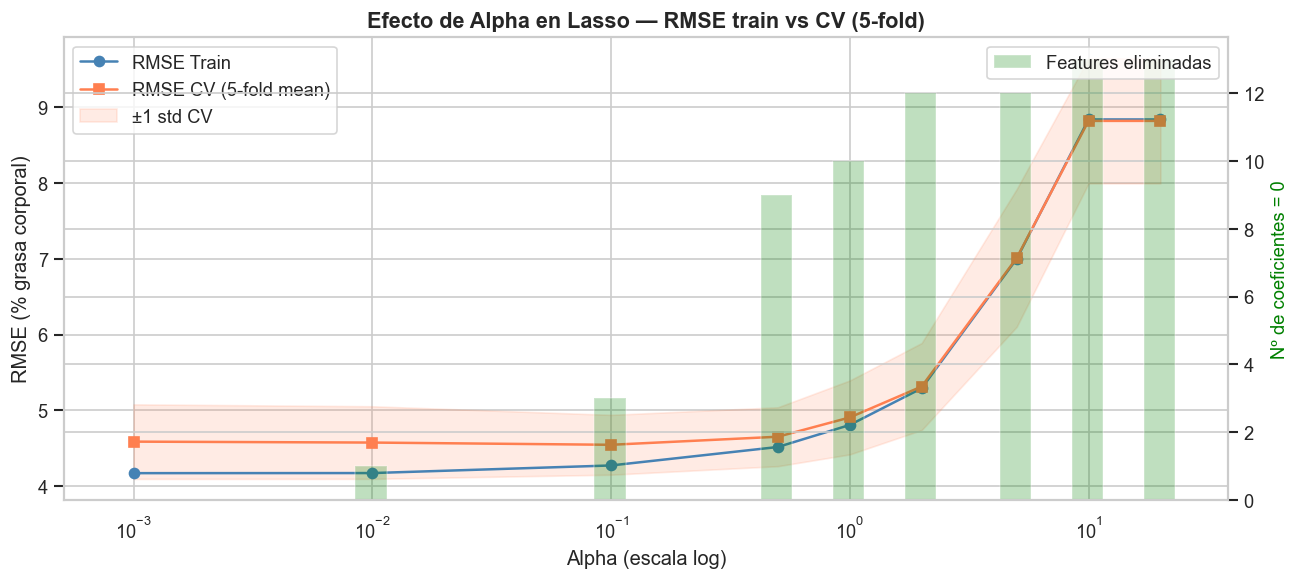

  Mejor alpha (mínimo RMSE CV): 0.1
  RMSE CV en ese alpha        : 4.5440 ± 0.3951


In [ ]:
# ── Exploración de alpha: 
from sklearn.model_selection import cross_val_score, KFold

alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
rmse_train_vals, rmse_cv_vals, rmse_cv_std, n_coef_nulos = [], [], [], []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for a in alphas:
    m = Lasso(alpha=a, random_state=42, max_iter=10000)

    # RMSE en train completo
    m.fit(X_train_scaled, y_train)
    rmse_train_vals.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train_scaled))))
    n_coef_nulos.append((m.coef_ == 0).sum())

    # RMSE CV (negativo por convención de sklearn → negamos y sacamos raíz)
    cv_scores = cross_val_score(
        Lasso(alpha=a, random_state=42, max_iter=10000),
        X_train_scaled, y_train,
        scoring='neg_mean_squared_error',
        cv=kf
    )
    rmse_cv = np.sqrt(-cv_scores)
    rmse_cv_vals.append(rmse_cv.mean())
    rmse_cv_std.append(rmse_cv.std())

rmse_cv_vals = np.array(rmse_cv_vals)
rmse_cv_std  = np.array(rmse_cv_std)

fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(alphas, rmse_train_vals, 'o-', color='steelblue', label='RMSE Train')
ax1.plot(alphas, rmse_cv_vals,    's-', color='coral',     label='RMSE CV (5-fold mean)')
ax1.fill_between(alphas,
                 rmse_cv_vals - rmse_cv_std,
                 rmse_cv_vals + rmse_cv_std,
                 color='coral', alpha=0.15, label='±1 std CV')
ax1.set_xscale('log')
ax1.set_xlabel('Alpha (escala log)', fontsize=12)
ax1.set_ylabel('RMSE (% grasa corporal)', fontsize=12)
ax1.legend(loc='upper left')
ax1.set_title('Efecto de Alpha en Lasso — RMSE train vs CV (5-fold)', fontsize=13, fontweight='bold')

ax2 = ax1.twinx()
ax2.bar(alphas, n_coef_nulos, width=[a*0.3 for a in alphas],
        alpha=0.25, color='green', label='Features eliminadas')
ax2.set_ylabel('Nº de coeficientes = 0', color='green', fontsize=11)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Mejor alpha según RMSE CV
best_alpha = alphas[np.argmin(rmse_cv_vals)]
print(f'  Mejor alpha (mínimo RMSE CV): {best_alpha}')
print(f'  RMSE CV en ese alpha        : {rmse_cv_vals[np.argmin(rmse_cv_vals)]:.4f} ± {rmse_cv_std[np.argmin(rmse_cv_vals)]:.4f}')

In [ ]:
# ── Lasso con el mejor alpha encontrado ───────────────────────────────────────
lasso_best = Lasso(alpha=best_alpha, random_state=42, max_iter=10000)
lasso_best.fit(X_train_scaled, y_train)

y_pred_lasso_best_train = lasso_best.predict(X_train_scaled)
y_pred_lasso_best_test  = lasso_best.predict(X_test_scaled)

print(f'=== Lasso (alpha={best_alpha}) — mejor según exploración ===')
print('Train:')
res_lasso_best_train = evaluar_modelo(f'Lasso α={best_alpha} (train)', y_train, y_pred_lasso_best_train)
print('Test:')
res_lasso_best_test  = evaluar_modelo(f'Lasso α={best_alpha} (test)',  y_test,  y_pred_lasso_best_test)
resultados.append(res_lasso_best_test)
print(f'\n  Coeficientes NO nulos: {(lasso_best.coef_ != 0).sum()} / {len(lasso_best.coef_)}')

=== Lasso (alpha=0.1) — mejor según exploración ===
Train:
  Lasso α=0.1 (train)                  RMSE: 4.2710  |  MAE: 3.5649  |  R²: 0.7666
Test:
  Lasso α=0.1 (test)                   RMSE: 4.6425  |  MAE: 3.5111  |  R²: 0.5214

  Coeficientes NO nulos: 10 / 13


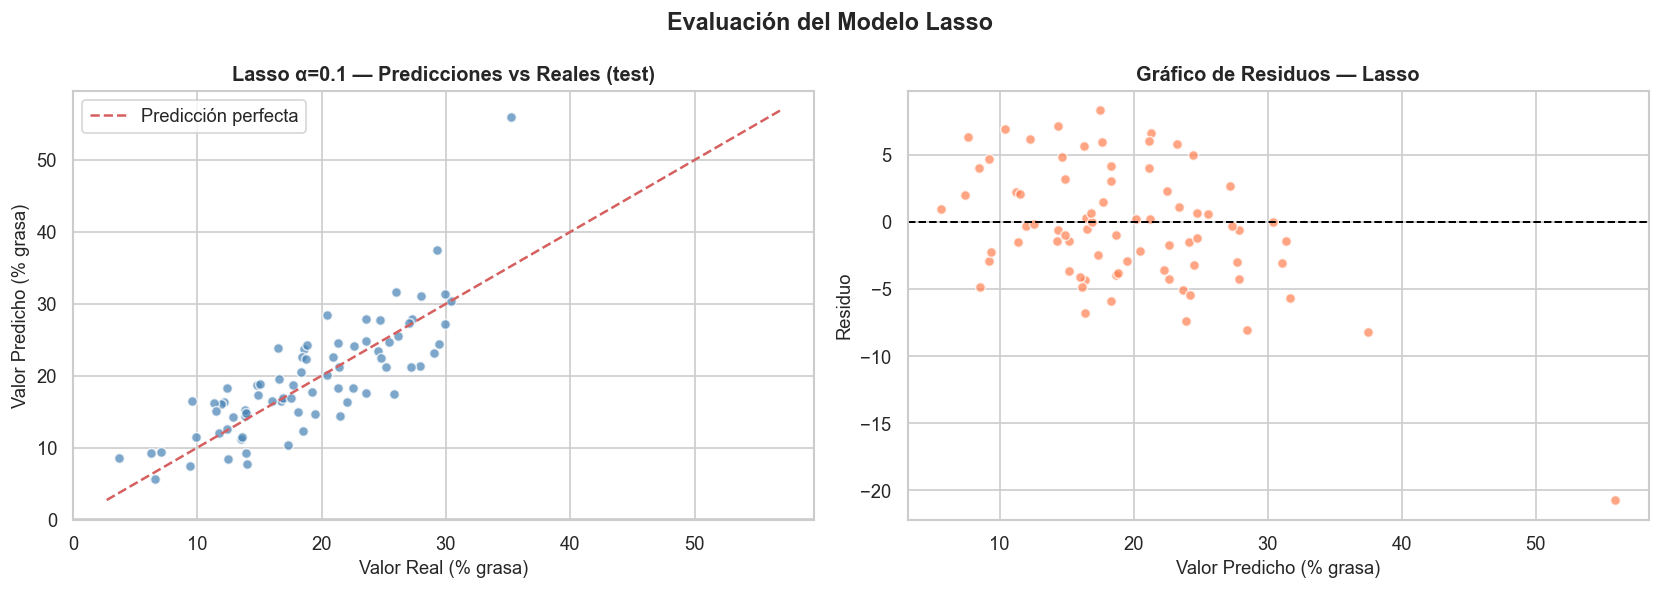

  Residuo medio   : -0.4693
  Residuo std     : 4.6494
  Residuo máx abs : 20.7173


In [ ]:
# ── Gráfico: Predicciones vs Valores Reales — Lasso best ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pred vs Real
ax = axes[0]
ax.scatter(y_test, y_pred_lasso_best_test, alpha=0.7, s=35, color='steelblue', edgecolors='white')
lims = [min(y_test.min(), y_pred_lasso_best_test.min()) - 1,
        max(y_test.max(), y_pred_lasso_best_test.max()) + 1]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Valor Real (% grasa)', fontsize=11)
ax.set_ylabel('Valor Predicho (% grasa)', fontsize=11)
ax.set_title(f'Lasso α={best_alpha} — Predicciones vs Reales (test)', fontsize=12, fontweight='bold')
ax.legend()

# Residuos
residuos = y_test - y_pred_lasso_best_test
ax = axes[1]
ax.scatter(y_pred_lasso_best_test, residuos, alpha=0.7, s=35, color='coral', edgecolors='white')
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Valor Predicho (% grasa)', fontsize=11)
ax.set_ylabel('Residuo', fontsize=11)
ax.set_title('Gráfico de Residuos — Lasso', fontsize=12, fontweight='bold')

plt.suptitle('Evaluación del Modelo Lasso', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'  Residuo medio   : {residuos.mean():.4f}')
print(f'  Residuo std     : {residuos.std():.4f}')
print(f'  Residuo máx abs : {residuos.abs().max():.4f}')

=== Resumen de modelos — Fase 4 ===
            Modelo   RMSE    MAE      R²
Lasso α=0.1 (test) 4.6425 3.5111  0.5214
      Dummy (test) 6.7151 5.5959 -0.0014


C:\Users\aye_c\AppData\Local\Temp\ipykernel_30476\146116234.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(resumen_df['Modelo'], rotation=20, ha='right', fontsize=9)
C:\Users\aye_c\AppData\Local\Temp\ipykernel_30476\146116234.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(resumen_df['Modelo'], rotation=20, ha='right', fontsize=9)
C:\Users\aye_c\AppData\Local\Temp\ipykernel_30476\146116234.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(resumen_df['Modelo'], rotation=20, ha='right', fontsize=9)


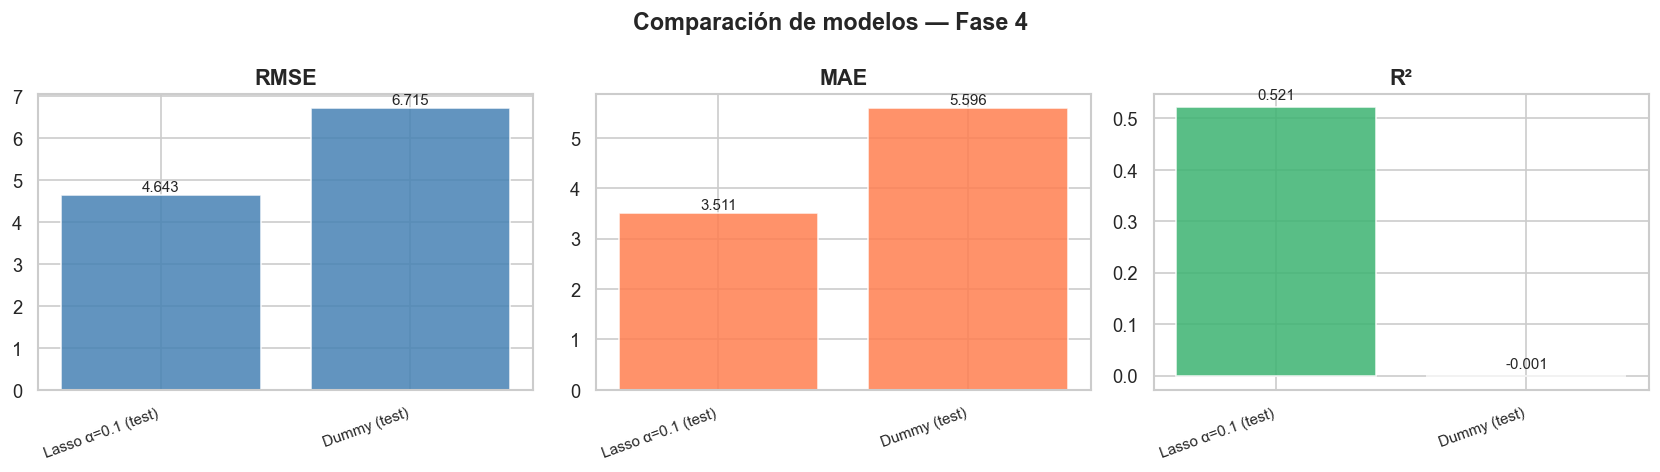

In [ ]:
# ── Tabla resumen de modelos Fase 4 ──────────────────────────────────────────
resumen_df = pd.DataFrame(resultados)
resumen_df = resumen_df.sort_values('RMSE')

print('=== Resumen de modelos — Fase 4 ===')
print(resumen_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metricas = ['RMSE', 'MAE', 'R²']
colores  = ['steelblue', 'coral', 'mediumseagreen']

for i, (metrica, color) in enumerate(zip(metricas, colores)):
    ax = axes[i]
    bars = ax.bar(resumen_df['Modelo'], resumen_df[metrica], color=color, edgecolor='white', alpha=0.85)
    ax.set_title(metrica, fontsize=13, fontweight='bold')
    ax.set_xticklabels(resumen_df['Modelo'], rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, resumen_df[metrica]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparación de modelos — Fase 4', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 16. Regresión Lineal Múltiple (OLS)

Como punto de comparación entre el baseline y Lasso, entrenamos una **Regresión Lineal por Mínimos Cuadrados Ordinarios (OLS)**.  
A diferencia de Lasso, OLS no aplica ninguna penalización: ajusta todos los coeficientes libremente para minimizar el error cuadrático en train.

> Dado que el dataset tiene alta multicolinealidad (visto en Fase 2), esperamos que OLS sea más inestable que Lasso y que generalice peor al test set.

=== Regresión Lineal (OLS) ===
Train:
  Regresión Lineal (train)             RMSE: 4.1693  |  MAE: 3.4395  |  R²: 0.7776
Test:
  Regresión Lineal (test)              RMSE: 4.6075  |  MAE: 3.6885  |  R²: 0.5286

  Intercepto: 19.2483

=== Coeficientes OLS (ordenados por magnitud absoluta) ===
Feature  Coeficiente
Abdomen    11.504439
 Weight    -3.468205
  Wrist    -1.732967
    Hip    -1.677253
  Thigh     1.218245
 Biceps     0.867920
  Ankle     0.784329
    Age     0.737478
  Chest    -0.453923
   Neck    -0.371353
Forearm     0.249881
   Knee     0.016816
 Height    -0.009010


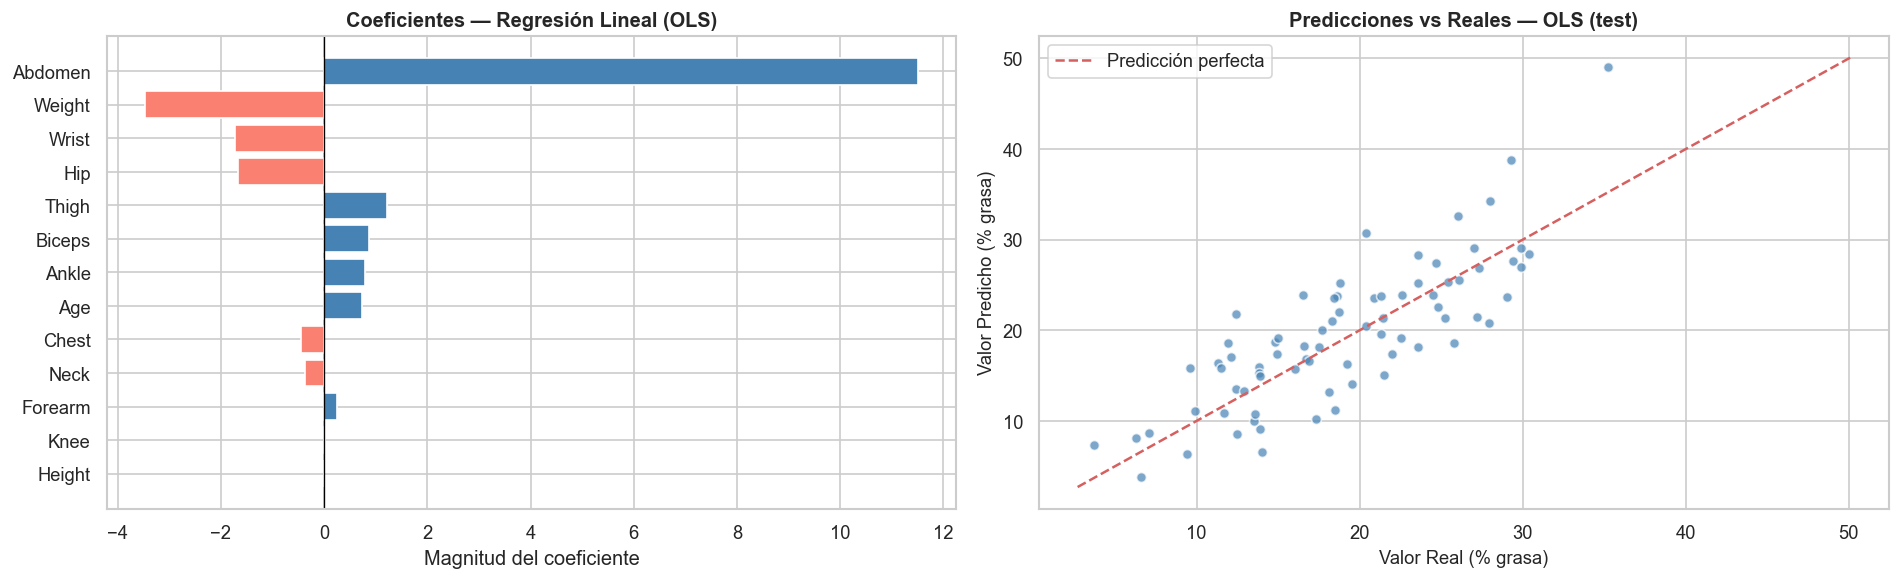

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr_test  = lr.predict(X_test_scaled)

print('=== Regresión Lineal (OLS) ===')
print('Train:')
res_lr_train = evaluar_modelo('Regresión Lineal (train)', y_train, y_pred_lr_train)
print('Test:')
res_lr_test  = evaluar_modelo('Regresión Lineal (test)',  y_test,  y_pred_lr_test)
resultados.append(res_lr_test)

# ── Coeficientes ───────────────────────────────────────────────────────────────
coef_lr = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Coeficiente': lr.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print(f'\n  Intercepto: {lr.intercept_:.4f}')
print('\n=== Coeficientes OLS (ordenados por magnitud absoluta) ===')
print(coef_lr.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Coeficientes
ax = axes[0]
colors = ['steelblue' if v > 0 else 'salmon' for v in coef_lr['Coeficiente']]
ax.barh(coef_lr['Feature'], coef_lr['Coeficiente'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes — Regresión Lineal (OLS)', fontsize=12, fontweight='bold')
ax.set_xlabel('Magnitud del coeficiente')
ax.invert_yaxis()

# Predicciones vs Reales
ax = axes[1]
ax.scatter(y_test, y_pred_lr_test, alpha=0.7, s=35, color='steelblue', edgecolors='white')
lims = [min(y_test.min(), y_pred_lr_test.min()) - 1,
        max(y_test.max(), y_pred_lr_test.max()) + 1]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Valor Real (% grasa)', fontsize=11)
ax.set_ylabel('Valor Predicho (% grasa)', fontsize=11)
ax.set_title('Predicciones vs Reales — OLS (test)', fontsize=12, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()



=== Resumen de todos los modelos (test set) ===
                 Modelo   RMSE    MAE      R²
Regresión Lineal (test) 4.6075 3.6885  0.5286
     Lasso α=0.1 (test) 4.6425 3.5111  0.5214
           Dummy (test) 6.7151 5.5959 -0.0014


C:\Users\aye_c\AppData\Local\Temp\ipykernel_30476\3183610084.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(resumen_completo['Modelo'], rotation=25, ha='right', fontsize=8)
C:\Users\aye_c\AppData\Local\Temp\ipykernel_30476\3183610084.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(resumen_completo['Modelo'], rotation=25, ha='right', fontsize=8)
C:\Users\aye_c\AppData\Local\Temp\ipykernel_30476\3183610084.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(resumen_completo['Modelo'], rotation=25, ha='right', fontsize=8)


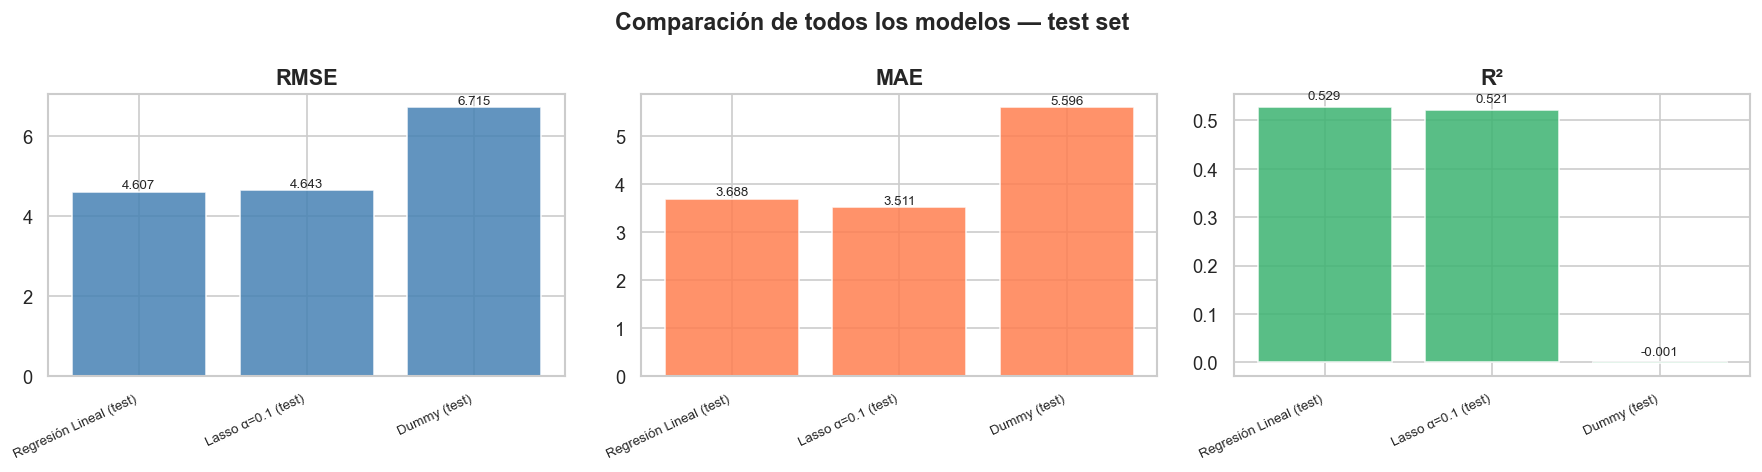

In [ ]:
# ── Comparación de todos los modelos testeados ────────────────────────────────
print('\n=== Resumen de todos los modelos (test set) ===')
resumen_completo = pd.DataFrame(resultados).sort_values('RMSE').reset_index(drop=True)
print(resumen_completo.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metricas = ['RMSE', 'MAE', 'R²']
colores  = ['steelblue', 'coral', 'mediumseagreen']

for i, (metrica, color) in enumerate(zip(metricas, colores)):
    ax = axes[i]
    bars = ax.bar(resumen_completo['Modelo'], resumen_completo[metrica],
                  color=color, edgecolor='white', alpha=0.85)
    ax.set_title(metrica, fontsize=13, fontweight='bold')
    ax.set_xticklabels(resumen_completo['Modelo'], rotation=25, ha='right', fontsize=8)
    for bar, val in zip(bars, resumen_completo[metrica]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparación de todos los modelos — test set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 17. Support Vector Regressor (SVR)

SVR busca un hiperplano que ajuste los datos dentro de un margen de tolerancia ε, ignorando errores pequeños y penalizando solo los que lo superan.  
Probamos dos kernels:
- **Lineal**: asume una relación lineal entre features y target (comparable a OLS pero con margen).  
- **RBF**: proyecta los datos a un espacio de mayor dimensión, capturando relaciones no lineales.

> El escalado aplicado en Fase 3 es fundamental aquí: SVR es muy sensible a la escala de las variables.


Fitting 5 folds for each of 80 candidates, totalling 400 fits

Mejores hiperparámetros : {'C': 100.0, 'epsilon': 1.0, 'gamma': 0.01, 'kernel': 'rbf'}
RMSE CV (mejor config)  : 4.7725

=== SVR (mejor config) ===
Train:
  SVR optimizado (train)               RMSE: 3.8156  |  MAE: 2.9672  |  R²: 0.8137
Test:
  SVR optimizado (test)                RMSE: 4.2921  |  MAE: 3.5515  |  R²: 0.5909


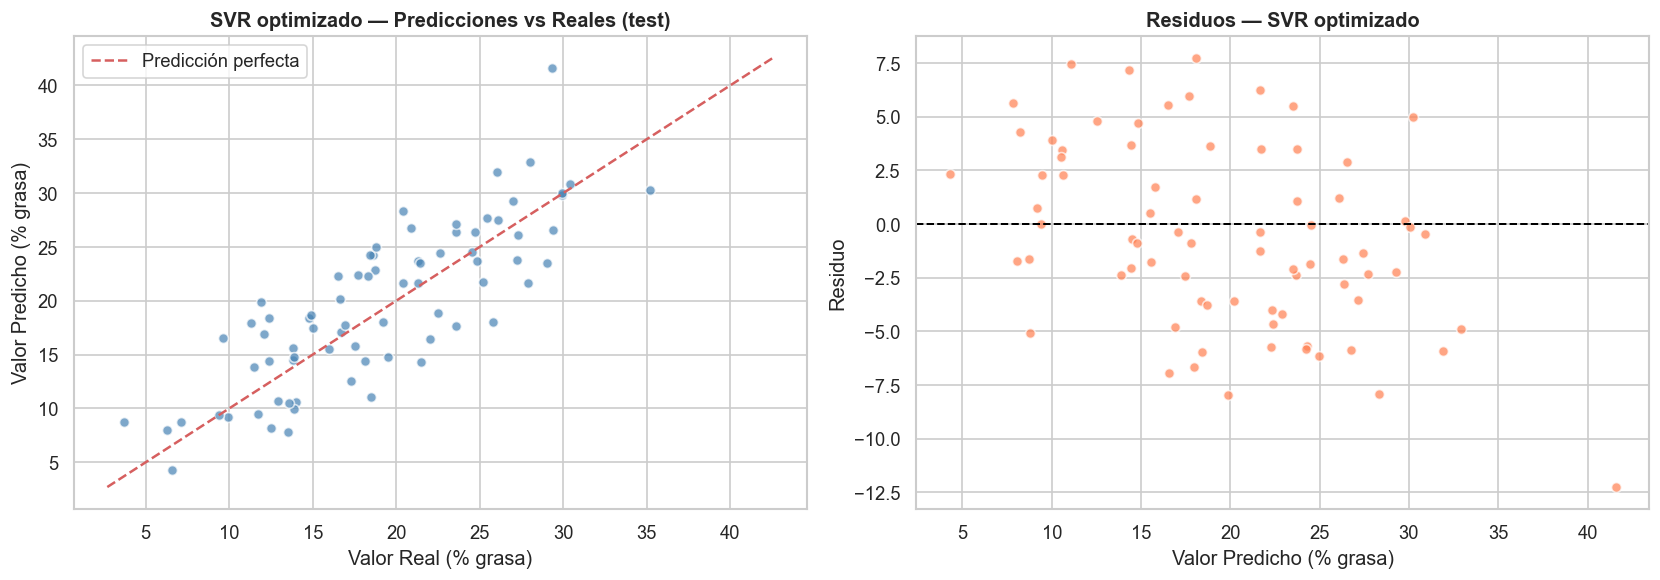


=== Resumen de todos los modelos (test set) ===
                 Modelo   RMSE    MAE      R²
  SVR optimizado (test) 4.2921 3.5515  0.5909
Regresión Lineal (test) 4.6075 3.6885  0.5286
     Lasso α=0.1 (test) 4.6425 3.5111  0.5214
           Dummy (test) 6.7151 5.5959 -0.0014


In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

# ── Grid de hiperparámetros ────────────────────────────────────────────────────
param_grid = [
    {
        'kernel' : ['linear'],
        'C'      : [0.1, 1.0, 10.0, 100.0],
        'epsilon': [0.01, 0.1, 0.5, 1.0],
    },
    {
        'kernel' : ['rbf'],
        'C'      : [0.1, 1.0, 10.0, 100.0],
        'epsilon': [0.01, 0.1, 0.5, 1.0],
        'gamma'  : ['scale', 'auto', 0.01, 0.1],
    },
]

grid_svr = GridSearchCV(
    SVR(),
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_svr.fit(X_train_scaled, y_train)

print(f'\nMejores hiperparámetros : {grid_svr.best_params_}')
print(f'RMSE CV (mejor config)  : {-grid_svr.best_score_:.4f}')

# ── Evaluación del mejor modelo en test ───────────────────────────────────────
best_svr = grid_svr.best_estimator_

print('\n=== SVR (mejor config) ===')
print('Train:')
evaluar_modelo('SVR optimizado (train)', y_train, best_svr.predict(X_train_scaled))
print('Test:')
res_svr = evaluar_modelo('SVR optimizado (test)', y_test, best_svr.predict(X_test_scaled))
resultados.append(res_svr)

# ── Predicciones vs Reales ────────────────────────────────────────────────────
y_pred_svr = best_svr.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_test, y_pred_svr, alpha=0.7, s=35, color='steelblue', edgecolors='white')
lims = [min(y_test.min(), y_pred_svr.min()) - 1, max(y_test.max(), y_pred_svr.max()) + 1]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Valor Real (% grasa)')
ax.set_ylabel('Valor Predicho (% grasa)')
ax.set_title('SVR optimizado — Predicciones vs Reales (test)', fontsize=12, fontweight='bold')
ax.legend()

residuos_svr = y_test - y_pred_svr
ax = axes[1]
ax.scatter(y_pred_svr, residuos_svr, alpha=0.7, s=35, color='coral', edgecolors='white')
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Valor Predicho (% grasa)')
ax.set_ylabel('Residuo')
ax.set_title('Residuos — SVR optimizado', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Comparación actualizada ────────────────────────────────────────────────────
resumen_completo = pd.DataFrame(resultados).sort_values('RMSE').reset_index(drop=True)
print('\n=== Resumen de todos los modelos (test set) ===')
print(resumen_completo.to_string(index=False))


### 18. Random Forest

Ensamble de árboles de decisión entrenados sobre subconjuntos aleatorios de datos y features (bagging).  
Al promediar muchos árboles decorrelacionados reduce la varianza sin aumentar el sesgo, lo que lo hace robusto a outliers y multicolinealidad.

> A diferencia de SVR y Lasso, Random Forest **no requiere escalado** — los árboles trabajan con cortes en los valores originales. Aun así usamos `X_train_scaled` para mantener consistencia con el pipeline.


Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Mejores hiperparámetros : {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
RMSE CV (mejor config)  : 4.9247

=== Random Forest (mejor config) ===
Train:
  Random Forest (train)                RMSE: 2.1174  |  MAE: 1.6643  |  R²: 0.9426
Test:
  Random Forest (test)                 RMSE: 4.2793  |  MAE: 3.5494  |  R²: 0.5933


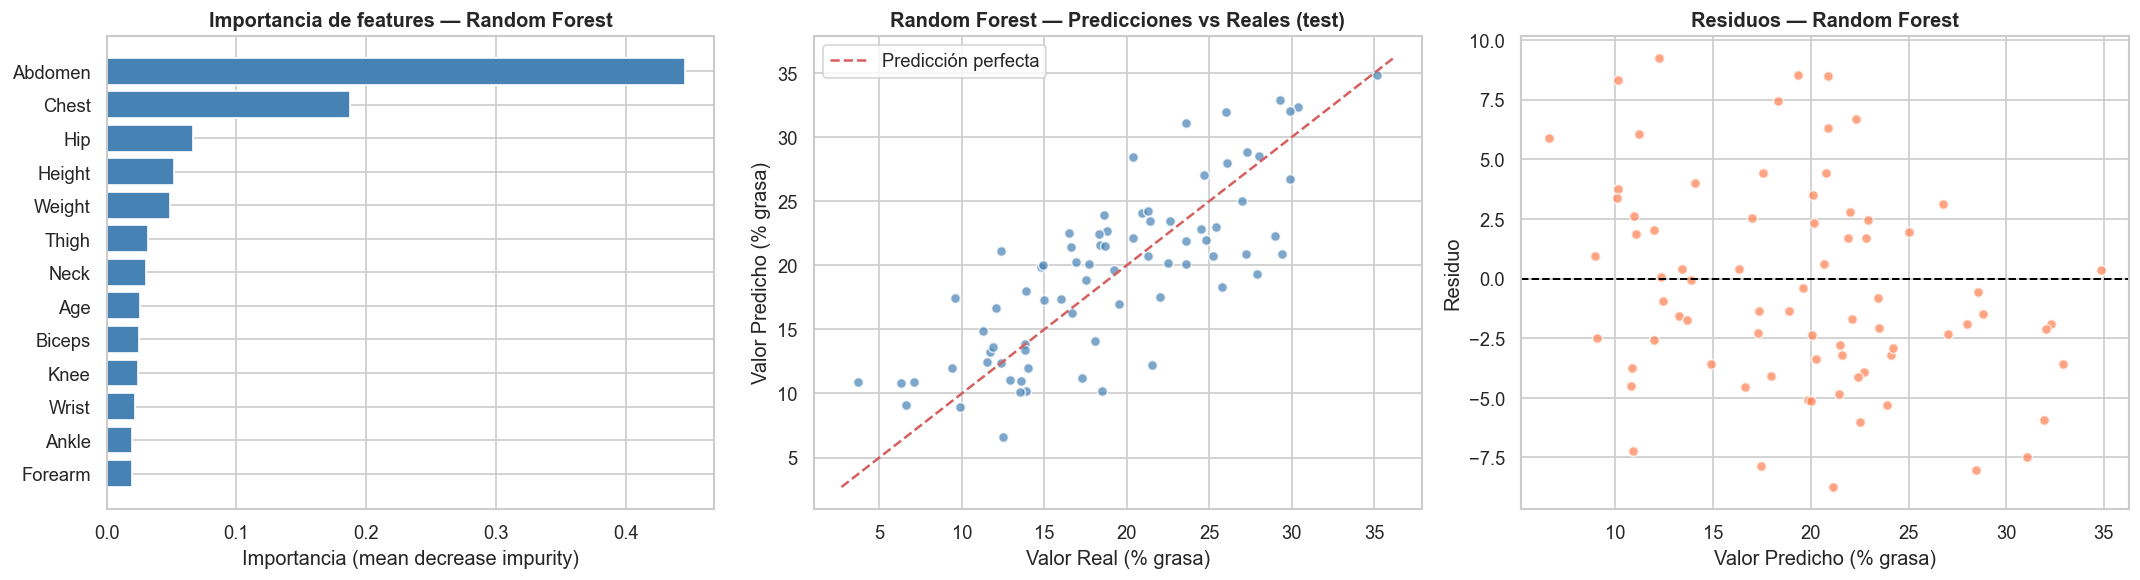


=== Resumen de todos los modelos (test set) ===
                 Modelo   RMSE    MAE      R²
   Random Forest (test) 4.2793 3.5494  0.5933
  SVR optimizado (test) 4.2921 3.5515  0.5909
Regresión Lineal (test) 4.6075 3.6885  0.5286
     Lasso α=0.1 (test) 4.6425 3.5111  0.5214
           Dummy (test) 6.7151 5.5959 -0.0014


In [ ]:
from sklearn.ensemble import RandomForestRegressor

param_grid_rf = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.5],
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train_scaled, y_train)

print(f'\nMejores hiperparámetros : {grid_rf.best_params_}')
print(f'RMSE CV (mejor config)  : {-grid_rf.best_score_:.4f}')

# ── Evaluación en test ────────────────────────────────────────────────────────
best_rf = grid_rf.best_estimator_

print('\n=== Random Forest (mejor config) ===')
print('Train:')
evaluar_modelo('Random Forest (train)', y_train, best_rf.predict(X_train_scaled))
print('Test:')
res_rf = evaluar_modelo('Random Forest (test)', y_test, best_rf.predict(X_test_scaled))
resultados.append(res_rf)

# ── Importancia de features ───────────────────────────────────────────────────
importancias = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Importancia': best_rf.feature_importances_
}).sort_values('Importancia', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Importancia
ax = axes[0]
ax.barh(importancias['Feature'], importancias['Importancia'], color='steelblue', edgecolor='white')
ax.set_title('Importancia de features — Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia (mean decrease impurity)')
ax.invert_yaxis()

# Predicciones vs Reales
y_pred_rf = best_rf.predict(X_test_scaled)
ax = axes[1]
ax.scatter(y_test, y_pred_rf, alpha=0.7, s=35, color='steelblue', edgecolors='white')
lims = [min(y_test.min(), y_pred_rf.min()) - 1, max(y_test.max(), y_pred_rf.max()) + 1]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Valor Real (% grasa)')
ax.set_ylabel('Valor Predicho (% grasa)')
ax.set_title('Random Forest — Predicciones vs Reales (test)', fontsize=12, fontweight='bold')
ax.legend()

# Residuos
residuos_rf = y_test - y_pred_rf
ax = axes[2]
ax.scatter(y_pred_rf, residuos_rf, alpha=0.7, s=35, color='coral', edgecolors='white')
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Valor Predicho (% grasa)')
ax.set_ylabel('Residuo')
ax.set_title('Residuos — Random Forest', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Comparación actualizada ───────────────────────────────────────────────────
resumen_completo = pd.DataFrame(resultados).sort_values('RMSE').reset_index(drop=True)
print('\n=== Resumen de todos los modelos (test set) ===')
print(resumen_completo.to_string(index=False))


### 19. Gradient Boosting

A diferencia de Random Forest (bagging en paralelo), Gradient Boosting construye árboles **secuencialmente**: cada árbol corrige los errores residuales del anterior.  
Usamos `HistGradientBoostingRegressor`, la implementación eficiente de sklearn inspirada en LightGBM, que maneja bien datasets pequeños y es significativamente más rápida que `GradientBoostingRegressor`.


Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Mejores hiperparámetros : {'l2_regularization': 1.0, 'learning_rate': 0.01, 'max_depth': 5, 'max_iter': 300, 'min_samples_leaf': 10}
RMSE CV (mejor config)  : 4.8860

=== Gradient Boosting (mejor config) ===
Train:
  Gradient Boosting (train)            RMSE: 2.5284  |  MAE: 1.9748  |  R²: 0.9182
Test:
  Gradient Boosting (test)             RMSE: 4.3650  |  MAE: 3.6959  |  R²: 0.5769


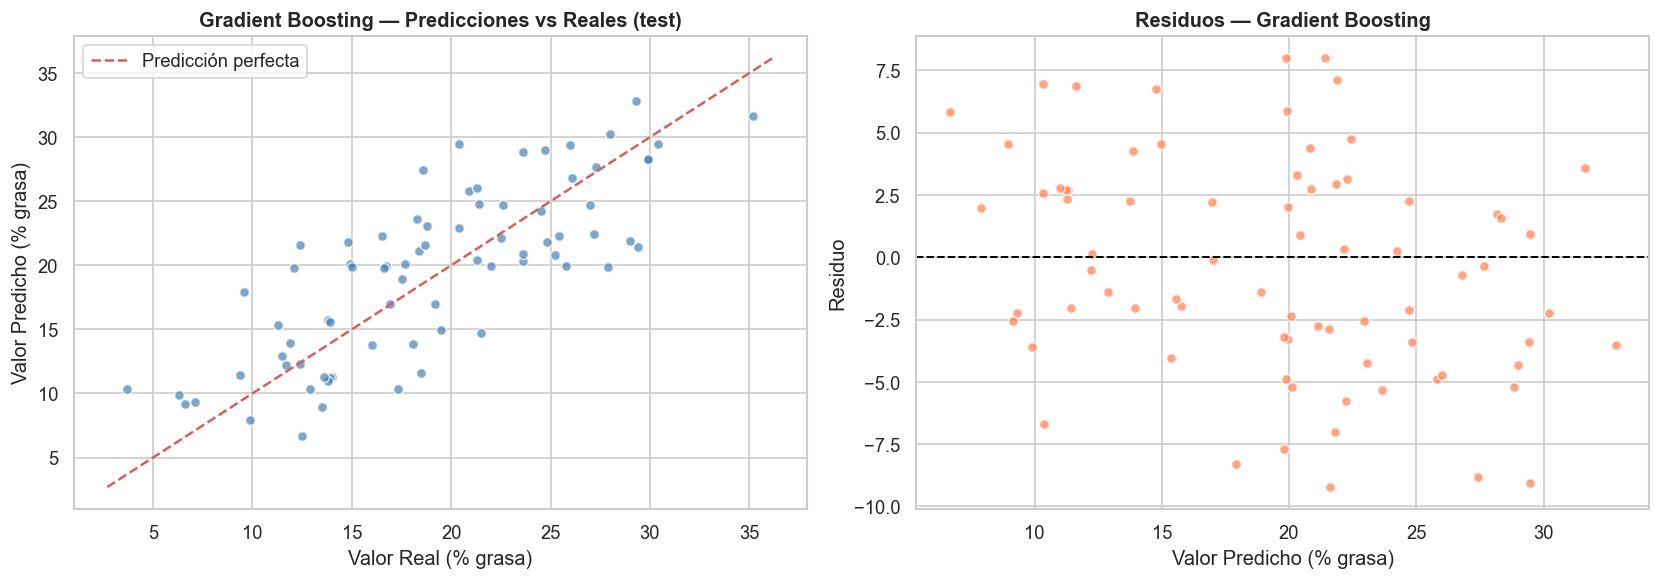


=== Ranking final de todos los modelos (test set) ===
                  Modelo   RMSE    MAE      R²
    Random Forest (test) 4.2793 3.5494  0.5933
   SVR optimizado (test) 4.2921 3.5515  0.5909
Gradient Boosting (test) 4.3650 3.6959  0.5769
 Regresión Lineal (test) 4.6075 3.6885  0.5286
      Lasso α=0.1 (test) 4.6425 3.5111  0.5214
            Dummy (test) 6.7151 5.5959 -0.0014


C:\Users\aye_c\AppData\Local\Temp\ipykernel_30476\4004940301.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(resumen_final['Modelo'], rotation=30, ha='right', fontsize=8)
C:\Users\aye_c\AppData\Local\Temp\ipykernel_30476\4004940301.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(resumen_final['Modelo'], rotation=30, ha='right', fontsize=8)
C:\Users\aye_c\AppData\Local\Temp\ipykernel_30476\4004940301.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(resumen_final['Modelo'], rotation=30, ha='right', fontsize=8)


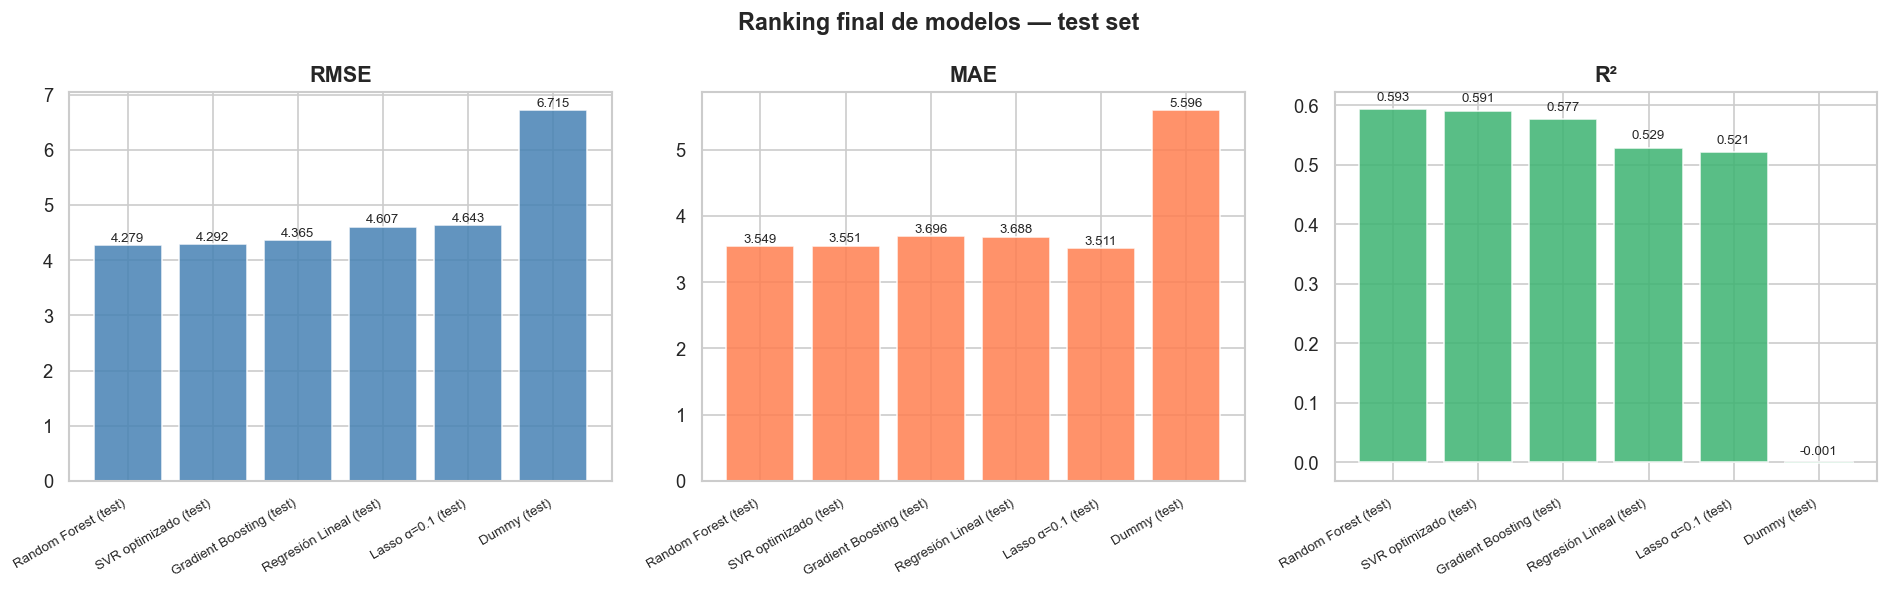

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

param_grid_hgb = {
    'max_iter'        : [100, 200, 300],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'max_depth'       : [3, 5, 7, None],
    'min_samples_leaf': [10, 20, 30],
    'l2_regularization': [0.0, 0.1, 1.0],
}

grid_hgb = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_grid_hgb,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_hgb.fit(X_train_scaled, y_train)

print(f'\nMejores hiperparámetros : {grid_hgb.best_params_}')
print(f'RMSE CV (mejor config)  : {-grid_hgb.best_score_:.4f}')

# ── Evaluación en test ────────────────────────────────────────────────────────
best_hgb = grid_hgb.best_estimator_

print('\n=== Gradient Boosting (mejor config) ===')
print('Train:')
evaluar_modelo('Gradient Boosting (train)', y_train, best_hgb.predict(X_train_scaled))
print('Test:')
res_hgb = evaluar_modelo('Gradient Boosting (test)', y_test, best_hgb.predict(X_test_scaled))
resultados.append(res_hgb)

# ── Gráficos ──────────────────────────────────────────────────────────────────
y_pred_hgb = best_hgb.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_test, y_pred_hgb, alpha=0.7, s=35, color='steelblue', edgecolors='white')
lims = [min(y_test.min(), y_pred_hgb.min()) - 1, max(y_test.max(), y_pred_hgb.max()) + 1]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Valor Real (% grasa)')
ax.set_ylabel('Valor Predicho (% grasa)')
ax.set_title('Gradient Boosting — Predicciones vs Reales (test)', fontsize=12, fontweight='bold')
ax.legend()

residuos_hgb = y_test - y_pred_hgb
ax = axes[1]
ax.scatter(y_pred_hgb, residuos_hgb, alpha=0.7, s=35, color='coral', edgecolors='white')
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Valor Predicho (% grasa)')
ax.set_ylabel('Residuo')
ax.set_title('Residuos — Gradient Boosting', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Comparación final de todos los modelos ────────────────────────────────────
resumen_final = pd.DataFrame(resultados).sort_values('RMSE').reset_index(drop=True)
print('\n=== Ranking final de todos los modelos (test set) ===')
print(resumen_final.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metricas = ['RMSE', 'MAE', 'R²']
colores  = ['steelblue', 'coral', 'mediumseagreen']

for i, (metrica, color) in enumerate(zip(metricas, colores)):
    ax = axes[i]
    bars = ax.bar(resumen_final['Modelo'], resumen_final[metrica],
                  color=color, edgecolor='white', alpha=0.85)
    ax.set_title(metrica, fontsize=13, fontweight='bold')
    ax.set_xticklabels(resumen_final['Modelo'], rotation=30, ha='right', fontsize=8)
    for bar, val in zip(bars, resumen_final[metrica]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Ranking final de modelos — test set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 20.Conclusiones

### Ranking y rendimiento general

Todos los modelos superaron ampliamente al baseline (RMSE 6.72), validando que las features del dataset tienen poder predictivo real sobre el porcentaje de grasa corporal.

Los modelos no lineales (Random Forest, SVR, Gradient Boosting) superaron consistentemente a los lineales, con una diferencia de ~0.3–0.4 puntos de RMSE. Esto sugiere que existen relaciones no lineales entre las medidas corporales y la grasa que los modelos lineales
no logran capturar completamente.

### Modelos seleccionados

**Random Forest** y **SVR** quedaron prácticamente empatados en el primer puesto (RMSE 4.28 vs 4.29, R² 0.593 vs 0.591). La diferencia es estadísticamente insignificante, por lo que la elección entre ambos depende del contexto:
- Random Forest es preferible cuando se necesita **interpretar qué variables importan**
  (feature importances).
- SVR es preferible cuando la prioridad es **simplicidad del modelo** y no se necesita
  explicabilidad.

**Lasso (α=0.1)** fue el mejor modelo lineal en MAE (3.51), incluso por debajo de OLS (3.69), lo que confirma que la penalización L1 ayuda a reducir errores individuales al eliminar ruido de variables poco relevantes, aunque no mejora el RMSE global.


Adicionalmente, el análisis de residuos de todos los modelos muestra una distribución aproximadamente uniforme y centrada en cero, sin patrones sistemáticos evidentes, lo que valida el supuesto de linealidad y confirma que los errores son aleatorios.

### Limitaciones

El R² máximo obtenido (~0.59) indica que los modelos explican aproximadamente el 60% de la varianza del target. El 40% restante probablemente se debe a la ausencia de "Density" (excluida por data leakage) y al tamaño reducido del dataset (n ≈ 200 en entrenamiento).


## Ejercicio extra

Durante la evaluación de los modelos se observó una brecha considerable entre algunas métricas de entrenamiento y de prueba, lo que podría indicar la presencia de sobreajuste y una limitada capacidad de generalización en muestras de tamaño reducido. En este contexto, se propone continuar trabajando con el modelo de Random Forest, dado que presentó el mejor desempeño general, y explorar alternativas para reducir dicha diferencia mediante el ajuste de los hiperparámetros que controlan la complejidad de los árboles, con el objetivo de mejorar su capacidad de generalización sin deteriorar significativamente su desempeño predictivo.

In [ ]:
# Ejercicio extra: reducción del sobreajuste en Random Forest

param_grid_rf_regularized = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 5, 7],        # restringimos — antes incluía None
    'min_samples_leaf' : [5, 10, 20],      # más restrictivo que [1, 2, 4]
    'min_samples_split': [5, 10, 20],
    'max_features'     : ['sqrt', 'log2'],
}

grid_rf_reg = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf_regularized,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_rf_reg.fit(X_train_scaled, y_train)

best_rf_reg = grid_rf_reg.best_estimator_

print(f'Mejores hiperparámetros : {grid_rf_reg.best_params_}')
print(f'RMSE CV (mejor config)  : {-grid_rf_reg.best_score_:.4f}')

print('\n=== Random Forest regularizado ===')
print('Train:')
res_rf_reg_train = evaluar_modelo('RF regularizado (train)', y_train, best_rf_reg.predict(X_train_scaled))
print('Test:')
res_rf_reg_test  = evaluar_modelo('RF regularizado (test)',  y_test,  best_rf_reg.predict(X_test_scaled))

# ── Comparación: RF original vs RF regularizado ───────────────────────────────
print('\n=== Comparación: RF original vs RF regularizado ===')
comp = pd.DataFrame([
    {'Modelo': 'RF original   ', **{k: v for k, v in res_rf.items()     if k != 'Modelo'}},
    {'Modelo': 'RF regularizado', **{k: v for k, v in res_rf_reg_test.items() if k != 'Modelo'}},
])
print(comp.to_string(index=False))


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Mejores hiperparámetros : {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 100}
RMSE CV (mejor config)  : 5.4739

=== Random Forest regularizado ===
Train:
  RF regularizado (train)              RMSE: 3.7162  |  MAE: 2.9600  |  R²: 0.8233
Test:
  RF regularizado (test)               RMSE: 4.3006  |  MAE: 3.5814  |  R²: 0.5893

=== Comparación: RF original vs RF regularizado ===
         Modelo   RMSE    MAE     R²
 RF original    4.2793 3.5494 0.5933
RF regularizado 4.3006 3.5814 0.5893


### Resultado

La regularización redujo el R² de entrenamiento a 0.82, pero la performance en test empeoró levemente (RMSE 4.30 vs 4.28). La brecha train/test persiste: con R² 0.82 en train y 0.59 en test, el modelo regularizado sigue mostrando sobreajuste moderado.

Esto confirma que la causa principal no es la complejidad del modelo sino el tamaño del dataset con pocas observaciones, cualquier ensamble de árboles tenderá a memorizar patrones específicos del train que no generalizan completamente.

Conclusión del ejercicio: la regularización no logró reducir la brecha train/test de forma significativa sin sacrificar performance en test. El modelo original obtenido por GridSearchCV con validación cruzada representaría el mejor  balance alcanzable para este dataset.